# 1. EDA

## 1.1 Dataset information

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("fff_2013j_student_week_raw_inactivity_filtered.csv")
df.head()

,id_student,code_module,code_presentation,week_t,days_since_start,inactivity_next_30d,clicks_1w,clicks_2w,clicks_3w,clicks_4w,...,failed_assessments_4w,weighted_score_4w,gender,age_band,region,highest_education,imd_band,disability,num_of_prev_attempts,studied_credits
0,26247,FFF,2013J,0,0,0,109,109,109,109,...,0,0,M,35-55,South East Region,HE Qualification,80-90%,N,2,60
1,26247,FFF,2013J,1,7,0,0,109,109,109,...,0,0,M,35-55,South East Region,HE Qualification,80-90%,N,2,60
2,26247,FFF,2013J,2,14,0,144,144,253,253,...,0,1100,M,35-55,South East Region,HE Qualification,80-90%,N,2,60
3,26247,FFF,2013J,3,21,0,114,258,258,367,...,0,1100,M,35-55,South East Region,HE Qualification,80-90%,N,2,60
4,29335,FFF,2013J,0,0,0,258,258,258,258,...,0,0,M,0-35,West Midlands Region,Lower Than A Level,40-50%,N,0,60


In [3]:
# Before preprocessing, there are 55874 observations.
len(df)

55874

### Variables Information

* **Target variable:**

  **inactivity_next_30d** (binary, 1 = student becomes inactive or unregisters within the next 30 days; 0 = otherwise)

  A student is labeled 1 if they either unregister or have no engagement (no clicks and no assessment submissions) during the next 30 days.


* **Features:**

There are 30 numerical features and 6 categorical features.

#### Numerical

**Temporal**

* **week_t:** Number of weeks since module presentation start.


**Engagement (rolling 4-week windows)**
All computed using information available up to week *t*.

* **clicks_1w:** Total clicks in current week.
* **clicks_2w:** Total clicks in last 2 weeks.
* **clicks_3w:** Total clicks in last 3 weeks.
* **clicks_4w:** Total clicks in last 4 weeks.
* **active_days_4w:** Number of distinct days with ≥1 click in the last 4 weeks.
* **engagement_slope_4w:** Linear trend (OLS slope) of weekly clicks over last 4 weeks.
* **click_std_4w:** Standard deviation of weekly clicks over last 4 weeks (engagement volatility).


**Clicks by activity type (rolling 4 weeks)**
Each variable represents total clicks of that activity type in the last 4 weeks.

* **clicks_<activity_type>_4w:**
  - clicks_dataplus_4w
  - clicks_dualpane_4w
  - clicks_forumng_4w
  - clicks_glossary_4w
  - clicks_homepage_4w
  - clicks_oucollaborate_4w
  - clicks_oucontent_4w
  - clicks_ouwiki_4w
  - clicks_page_4w
  - clicks_questionnaire_4w
  - clicks_quiz_4w
  - clicks_repeatactivity_4w
  - clicks_resource_4w
  - clicks_subpage_4w
  - clicks_url_4w


**Assessment (rolling 4 weeks)**

* **assess_submitted_4w:** Number of assessment submissions in last 4 weeks.
* **avg_score_4w:** Average assessment score in last 4 weeks (0 if no submissions, after imputation).
* **missed_assessments_4w:** Number of assessments missed (late or not submitted) in last 4 weeks.
* **failed_assessments_4w:** Number of failed assessments (score < 40) in last 4 weeks.
* **weighted_score_4w:** Sum of assessment scores weighted by assessment weight over last 4 weeks.


**Academic Background**

* **num_of_prev_attempts:** Number of previous attempts at this module.
* **studied_credits:** Total credits studied before the presentation.


#### Categorical

* **imd_band:** (Ordinal) Socioeconomic deprivation band of student’s residence area
* **highest_education:** (Ordinal) Education level.
* **age_band:** (Ordinal) Age category.

* **gender:** (Binary) F/M.
* **disability:** (Binary) Y/N.

* **region:** Student’s geographic region.


### Unit of Analysis

Each row represents: **id_student × week_t**

In [4]:
target = "inactivity_next_30d"
num_cols = [
            "week_t", "clicks_1w", "clicks_2w", "clicks_3w", "clicks_4w",
            "active_days_4w", "engagement_slope_4w", "click_std_4w",
            "clicks_dataplus_4w", "clicks_dualpane_4w",
            "clicks_forumng_4w", "clicks_glossary_4w", "clicks_homepage_4w",
            "clicks_oucollaborate_4w", "clicks_oucontent_4w", "clicks_ouwiki_4w", 
            "clicks_page_4w", "clicks_questionnaire_4w", "clicks_quiz_4w",
            "clicks_repeatactivity_4w", "clicks_resource_4w", "clicks_subpage_4w",
            "clicks_url_4w", "assess_submitted_4w", "avg_score_4w",
            "missed_assessments_4w", "failed_assessments_4w", "weighted_score_4w",
            "num_of_prev_attempts", "studied_credits"
            ]
print(len(num_cols))
cat_cols = [
            "gender", "age_band", "region", 
            "highest_education", "imd_band", "disability"
            ]
print(len(cat_cols))

30
6


## 1.2 Missing values

In [5]:
df.isnull().sum().sort_values(ascending = False)

avg_score_4w                19123
imd_band                     3050
engagement_slope_4w          2080
click_std_4w                 2080
id_student                      0
clicks_repeatactivity_4w        0
clicks_resource_4w              0
clicks_subpage_4w               0
clicks_url_4w                   0
assess_submitted_4w             0
missed_assessments_4w           0
failed_assessments_4w           0
clicks_questionnaire_4w         0
weighted_score_4w               0
gender                          0
age_band                        0
region                          0
highest_education               0
disability                      0
num_of_prev_attempts            0
clicks_quiz_4w                  0
clicks_ouwiki_4w                0
clicks_page_4w                  0
clicks_4w                       0
code_presentation               0
week_t                          0
days_since_start                0
inactivity_next_30d             0
clicks_1w                       0
clicks_2w     

**avg_score_4w** is filled with 0 because it is undefined when there are no submissions in the last four weeks; assigning 0 provides a neutral numerical value while the model can still rely on assess_submitted_4w to distinguish “no submission” from “low score.”

In [6]:
df["avg_score_4w"] = df["avg_score_4w"].fillna(0)

For **imd_band**, missing values likely reflect unavailable geographic deprivation data rather than low deprivation, so they are encoded as 0 alongside a separate `missing_imd` indicator to preserve information about missingness. The wrongly formatted value `"10-20"` is corrected to `"10-20%"` to ensure consistency with the valid categorical format used in `imd_band`.

In [7]:
df["imd_band"].value_counts()

imd_band
30-40%     6168
Oct-20     6057
20-30%     5545
50-60%     5500
40-50%     5195
80-90%     5062
70-80%     4905
90-100%    4880
60-70%     4805
0-10%      4707
Name: count, dtype: int64

In [8]:
# Replace wrongly formatted value
df["imd_band"] = df["imd_band"].replace("Oct-20", "10-20%")
df["imd_band"].value_counts()

imd_band
30-40%     6168
10-20%     6057
20-30%     5545
50-60%     5500
40-50%     5195
80-90%     5062
70-80%     4905
90-100%    4880
60-70%     4805
0-10%      4707
Name: count, dtype: int64

In [9]:
# Create missing indicator
df["missing_imd"] = df["imd_band"].isna()

# Fill missing imd_band with 0
df["imd_band"] = df["imd_band"].fillna(0)
df["missing_imd"]

0        False
1        False
2        False
3        False
4        False
         ...  
55869    False
55870    False
55871    False
55872    False
55873    False
Name: missing_imd, Length: 55874, dtype: bool

In [10]:
cat_cols.append("missing_imd")

**engagement_slope_4w** and **click_std_4w** are set to 0 when undefined because insufficient history implies no measurable trend or volatility, and zero represents the most neutral and interpretable assumption.

In [11]:
df["engagement_slope_4w"] = df["engagement_slope_4w"].fillna(0)
df["click_std_4w"] = df["click_std_4w"].fillna(0)

df.isnull().sum().sort_values(ascending = False)

id_student                  0
failed_assessments_4w       0
clicks_quiz_4w              0
clicks_repeatactivity_4w    0
clicks_resource_4w          0
clicks_subpage_4w           0
clicks_url_4w               0
assess_submitted_4w         0
avg_score_4w                0
missed_assessments_4w       0
weighted_score_4w           0
code_module                 0
gender                      0
age_band                    0
region                      0
highest_education           0
imd_band                    0
disability                  0
num_of_prev_attempts        0
studied_credits             0
clicks_questionnaire_4w     0
clicks_page_4w              0
clicks_ouwiki_4w            0
clicks_oucontent_4w         0
code_presentation           0
week_t                      0
days_since_start            0
inactivity_next_30d         0
clicks_1w                   0
clicks_2w                   0
clicks_3w                   0
clicks_4w                   0
active_days_4w              0
engagement

## 1.3 Outliers

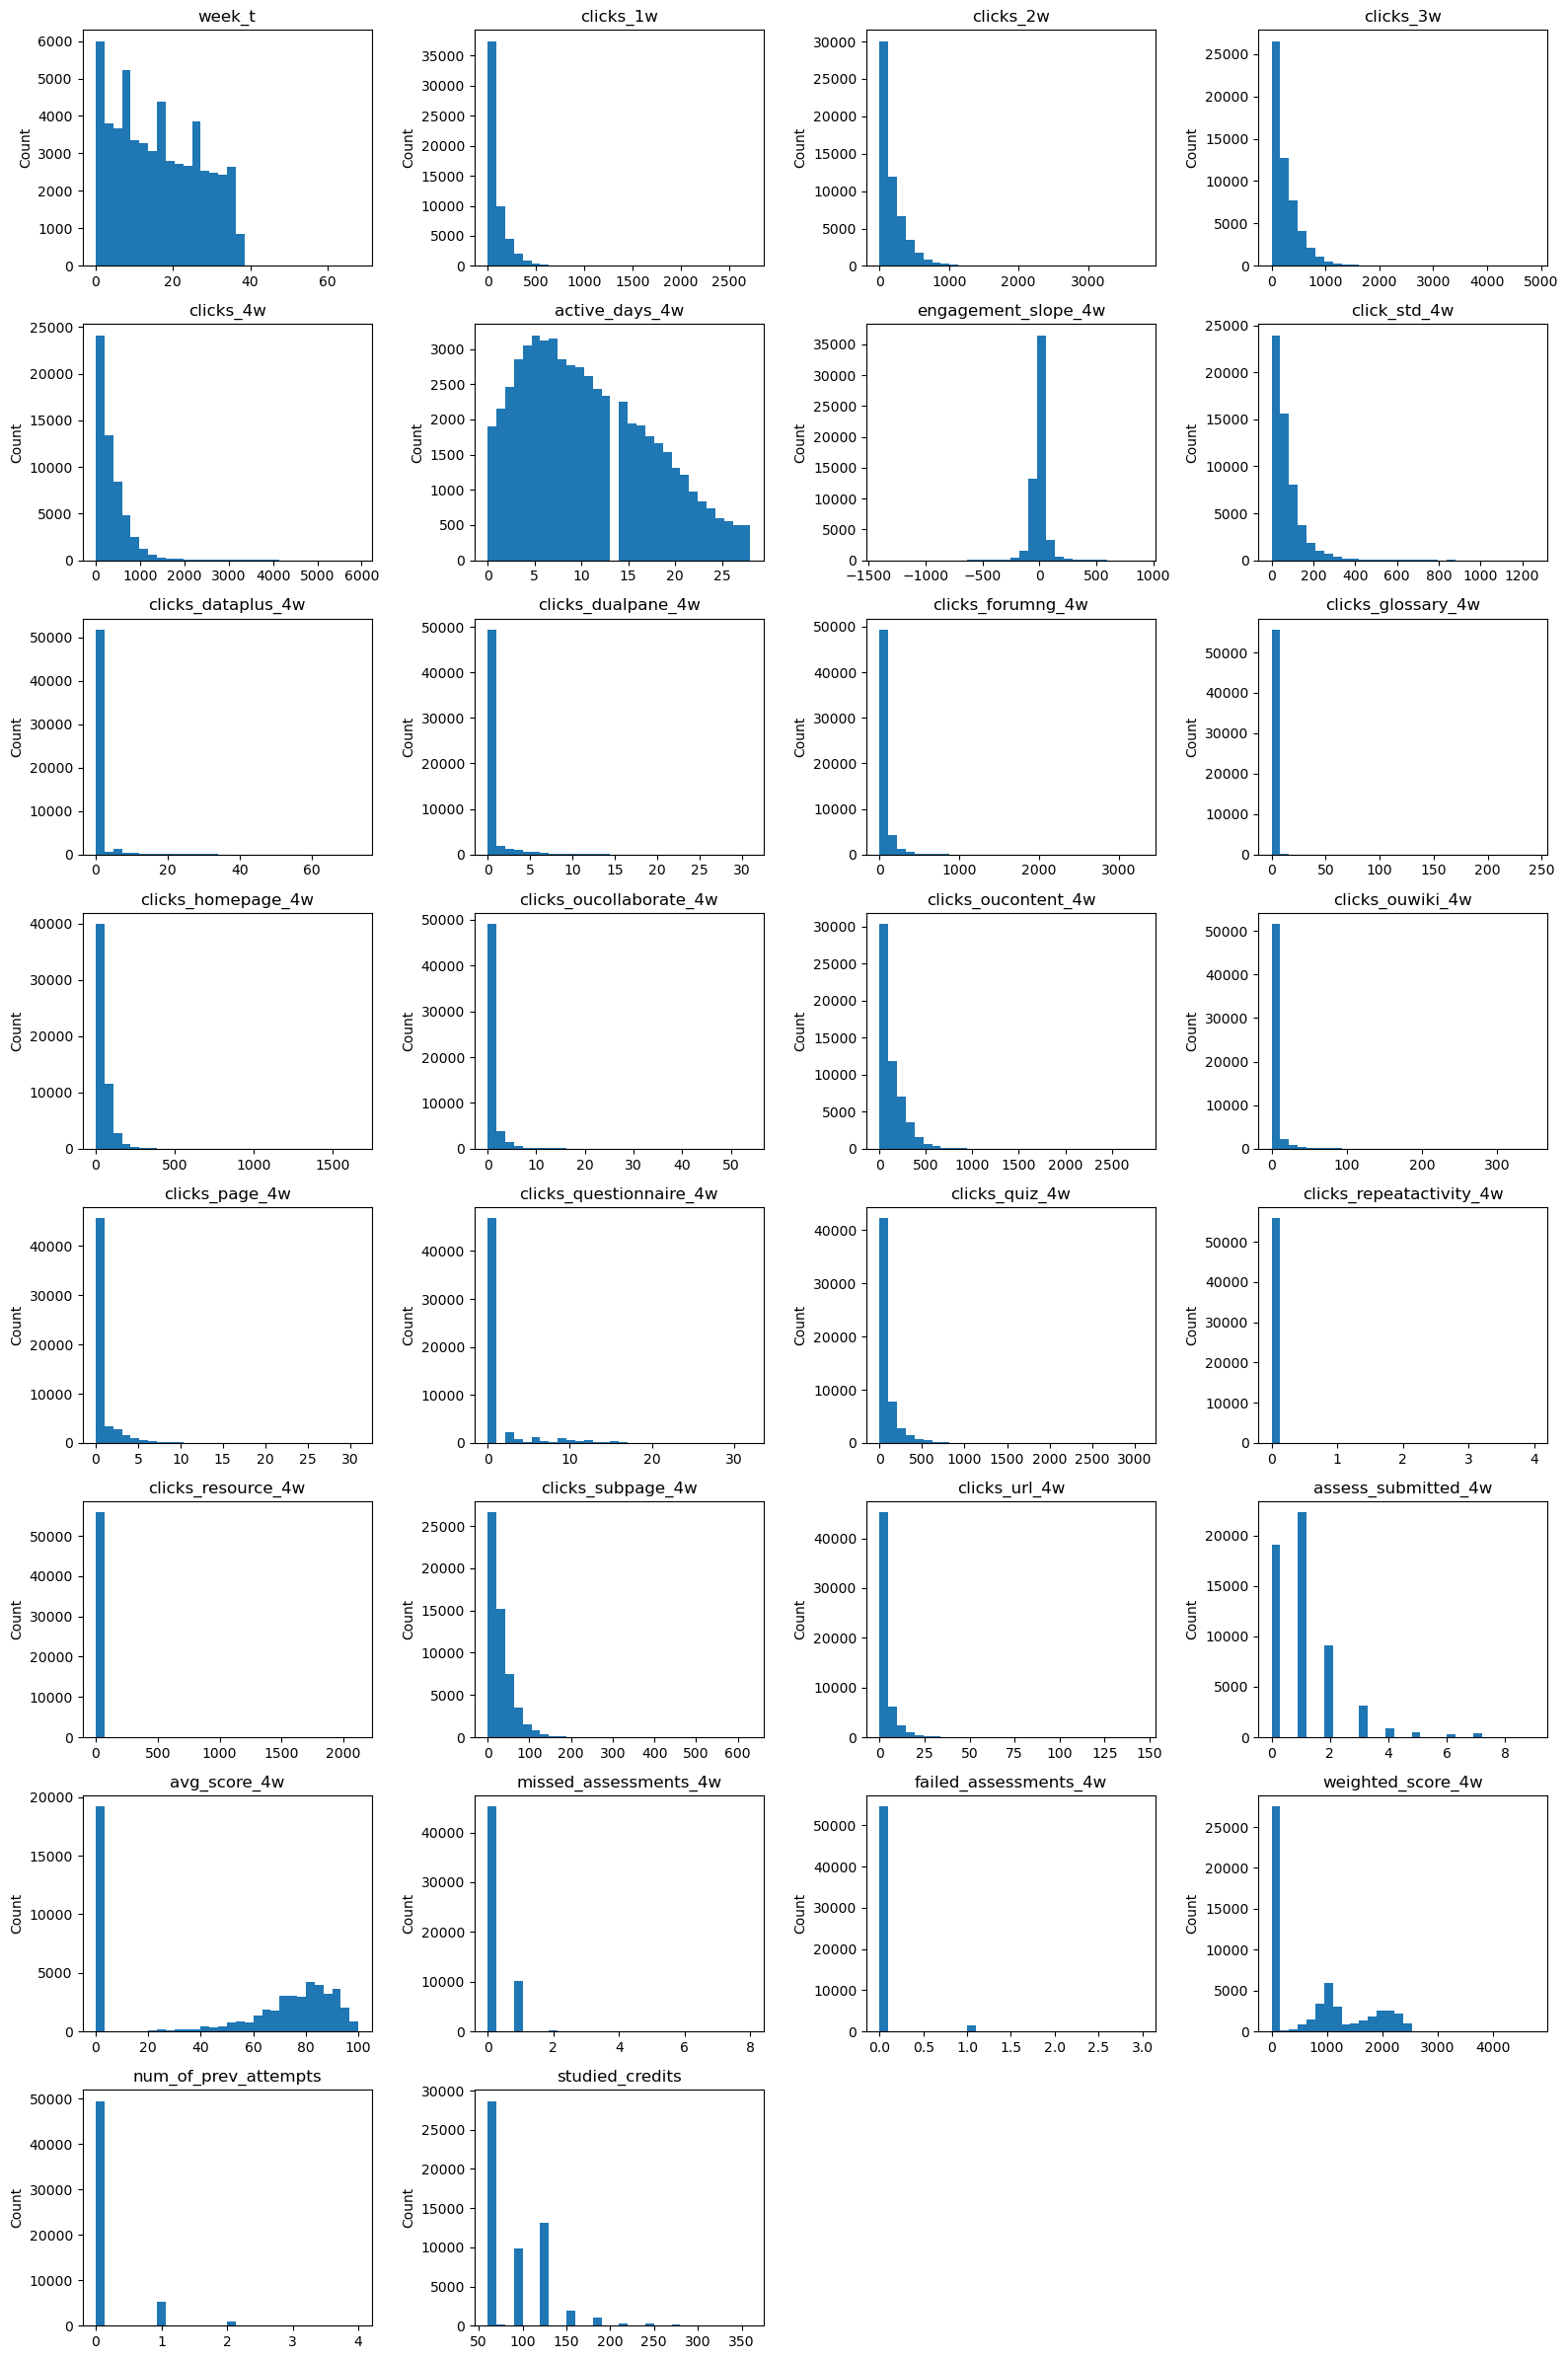

In [12]:
import math
import matplotlib.pyplot as plt

# number of columns per row
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

# create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

# plot histograms
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Activity features with fewer than 0.5% non-zero observations were removed to reduce noise and prevent overfitting, while moderately sparse features were retained as they may capture meaningful behavioral variation.

In [13]:
# Automatically drop ultra-rare activity features
# Threshold: non-zero ratio < 0.5%

threshold = 0.005 

# Identify activity features (4-week activity click features only)
activity_cols = [c for c in num_cols if c.startswith("clicks_") and c.endswith("_4w")]

cols_to_drop = []

for col in activity_cols:
    nonzero_ratio = (df[col] > 0).mean()
    if nonzero_ratio < threshold:
        cols_to_drop.append(col)

# Drop ultra-rare columns
num_cols = [col for col in num_cols if col not in cols_to_drop]

print("Dropped ultra-rare activity features:")
print(cols_to_drop)
print(f"Remaining activity features: {len(activity_cols) - len(cols_to_drop)}")

Dropped ultra-rare activity features:
['clicks_repeatactivity_4w']
Remaining activity features: 15


Outliers are dropped using the threshold of [Q1 - 1.5IQR, Q3 + 1.5IQR]

In [14]:
Q1 = df['clicks_1w'].quantile(0.25)
Q3 = df['clicks_1w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(3.0), np.float64(124.0), np.float64(-178.5), np.float64(305.5))

In [15]:
df.drop(df[df['clicks_1w'] > 305.5].index, inplace=True)
print(df.shape)

(52692, 42)


In [16]:
Q1 = df['clicks_2w'].quantile(0.25)
Q3 = df['clicks_2w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(17.0), np.float64(219.0), np.float64(-286.0), np.float64(522.0))

In [17]:
df.drop(df[df['clicks_2w'] > 522].index, inplace=True)
print(df.shape)

(51272, 42)


In [18]:
Q1 = df['clicks_3w'].quantile(0.25)
Q3 = df['clicks_3w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(43.0), np.float64(312.0), np.float64(-360.5), np.float64(715.5))

In [19]:
df.drop(df[df['clicks_3w'] > 715.5].index, inplace=True)
print(df.shape)

(50283, 42)


In [20]:
Q1 = df['clicks_4w'].quantile(0.25)
Q3 = df['clicks_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(75.0), np.float64(403.5), np.float64(-417.75), np.float64(896.25))

In [21]:
df.drop(df[df['clicks_4w'] > 896.25].index, inplace=True)
print(df.shape)

(49577, 42)


In [22]:
Q1 = df["engagement_slope_4w"].quantile(0.25)
Q3 = df['engagement_slope_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(-21.2),
 np.float64(9.1),
 np.float64(-66.64999999999999),
 np.float64(54.55))

In [23]:
df.drop(df[(df['engagement_slope_4w'] > 54.55) | (df['engagement_slope_4w'] < -66.65)].index, inplace=True)
print(df.shape)

(44834, 42)


In [24]:
Q1 = df["click_std_4w"].quantile(0.25)
Q3 = df['click_std_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(14.49999999999998),
 np.float64(67.41352484618544),
 np.float64(-64.87028726927821),
 np.float64(146.78381211546363))

In [25]:
df.drop(df[df['click_std_4w'] > 146.79].index, inplace=True)
print(df.shape)

(43872, 42)


In [26]:
Q1 = df["clicks_forumng_4w"].quantile(0.25)
Q3 = df['clicks_forumng_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(1.0), np.float64(41.0), np.float64(-59.0), np.float64(101.0))

In [27]:
df.drop(df[df['clicks_forumng_4w'] > 101.0].index, inplace=True)
print(df.shape)

(40548, 42)


In [28]:
Q1 = df["clicks_glossary_4w"].quantile(0.25)
Q3 = df['clicks_glossary_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0))

In [29]:
df["clicks_glossary_4w"].value_counts()

clicks_glossary_4w
0     40141
1       102
2        51
3        48
7        25
5        25
4        25
10       22
12       21
6        20
9        16
8        13
14       11
11        7
17        4
29        3
15        3
24        2
26        1
20        1
34        1
21        1
13        1
16        1
23        1
25        1
80        1
Name: count, dtype: int64

In [30]:
Q1 = df["clicks_homepage_4w"].quantile(0.25)
Q3 = df['clicks_homepage_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(10.0), np.float64(42.0), np.float64(-38.0), np.float64(90.0))

In [31]:
df.drop(df[df['clicks_homepage_4w'] > 90.0].index, inplace=True)
print(df.shape)

(39343, 42)


In [32]:
Q1 = df["clicks_oucontent_4w"].quantile(0.25)
Q3 = df['clicks_oucontent_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(10.0), np.float64(124.0), np.float64(-161.0), np.float64(295.0))

In [33]:
df.drop(df[df['clicks_oucontent_4w'] > 295.0].index, inplace=True)
print(df.shape)

(37989, 42)


In [34]:
Q1 = df["clicks_quiz_4w"].quantile(0.25)
Q3 = df['clicks_quiz_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(0.0), np.float64(52.0), np.float64(-78.0), np.float64(130.0))

In [35]:
df.drop(df[df['clicks_quiz_4w'] > 130.0].index, inplace=True)
print(df.shape)

(35019, 42)


In [36]:
Q1 = df["clicks_resource_4w"].quantile(0.25)
Q3 = df['clicks_resource_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(0.0), np.float64(4.0), np.float64(-6.0), np.float64(10.0))

In [37]:
df.drop(df[df['clicks_resource_4w'] > 10.0].index, inplace=True)
print(df.shape)

(32834, 42)


In [38]:
Q1 = df["clicks_subpage_4w"].quantile(0.25)
Q3 = df['clicks_subpage_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(4.0), np.float64(23.0), np.float64(-24.5), np.float64(51.5))

In [39]:
df.drop(df[df['clicks_resource_4w'] > 51.5].index, inplace=True)
print(df.shape)

(32834, 42)


In [40]:
Q1 = df["weighted_score_4w"].quantile(0.25)
Q3 = df['weighted_score_4w'].quantile(0.75)
IQR = Q3 - Q1
lower_thresh = Q1 - 1.5*IQR
upper_thresh = Q3 + 1.5*IQR
Q1, Q3, lower_thresh, upper_thresh

(np.float64(0.0), np.float64(1125.0), np.float64(-1687.5), np.float64(2812.5))

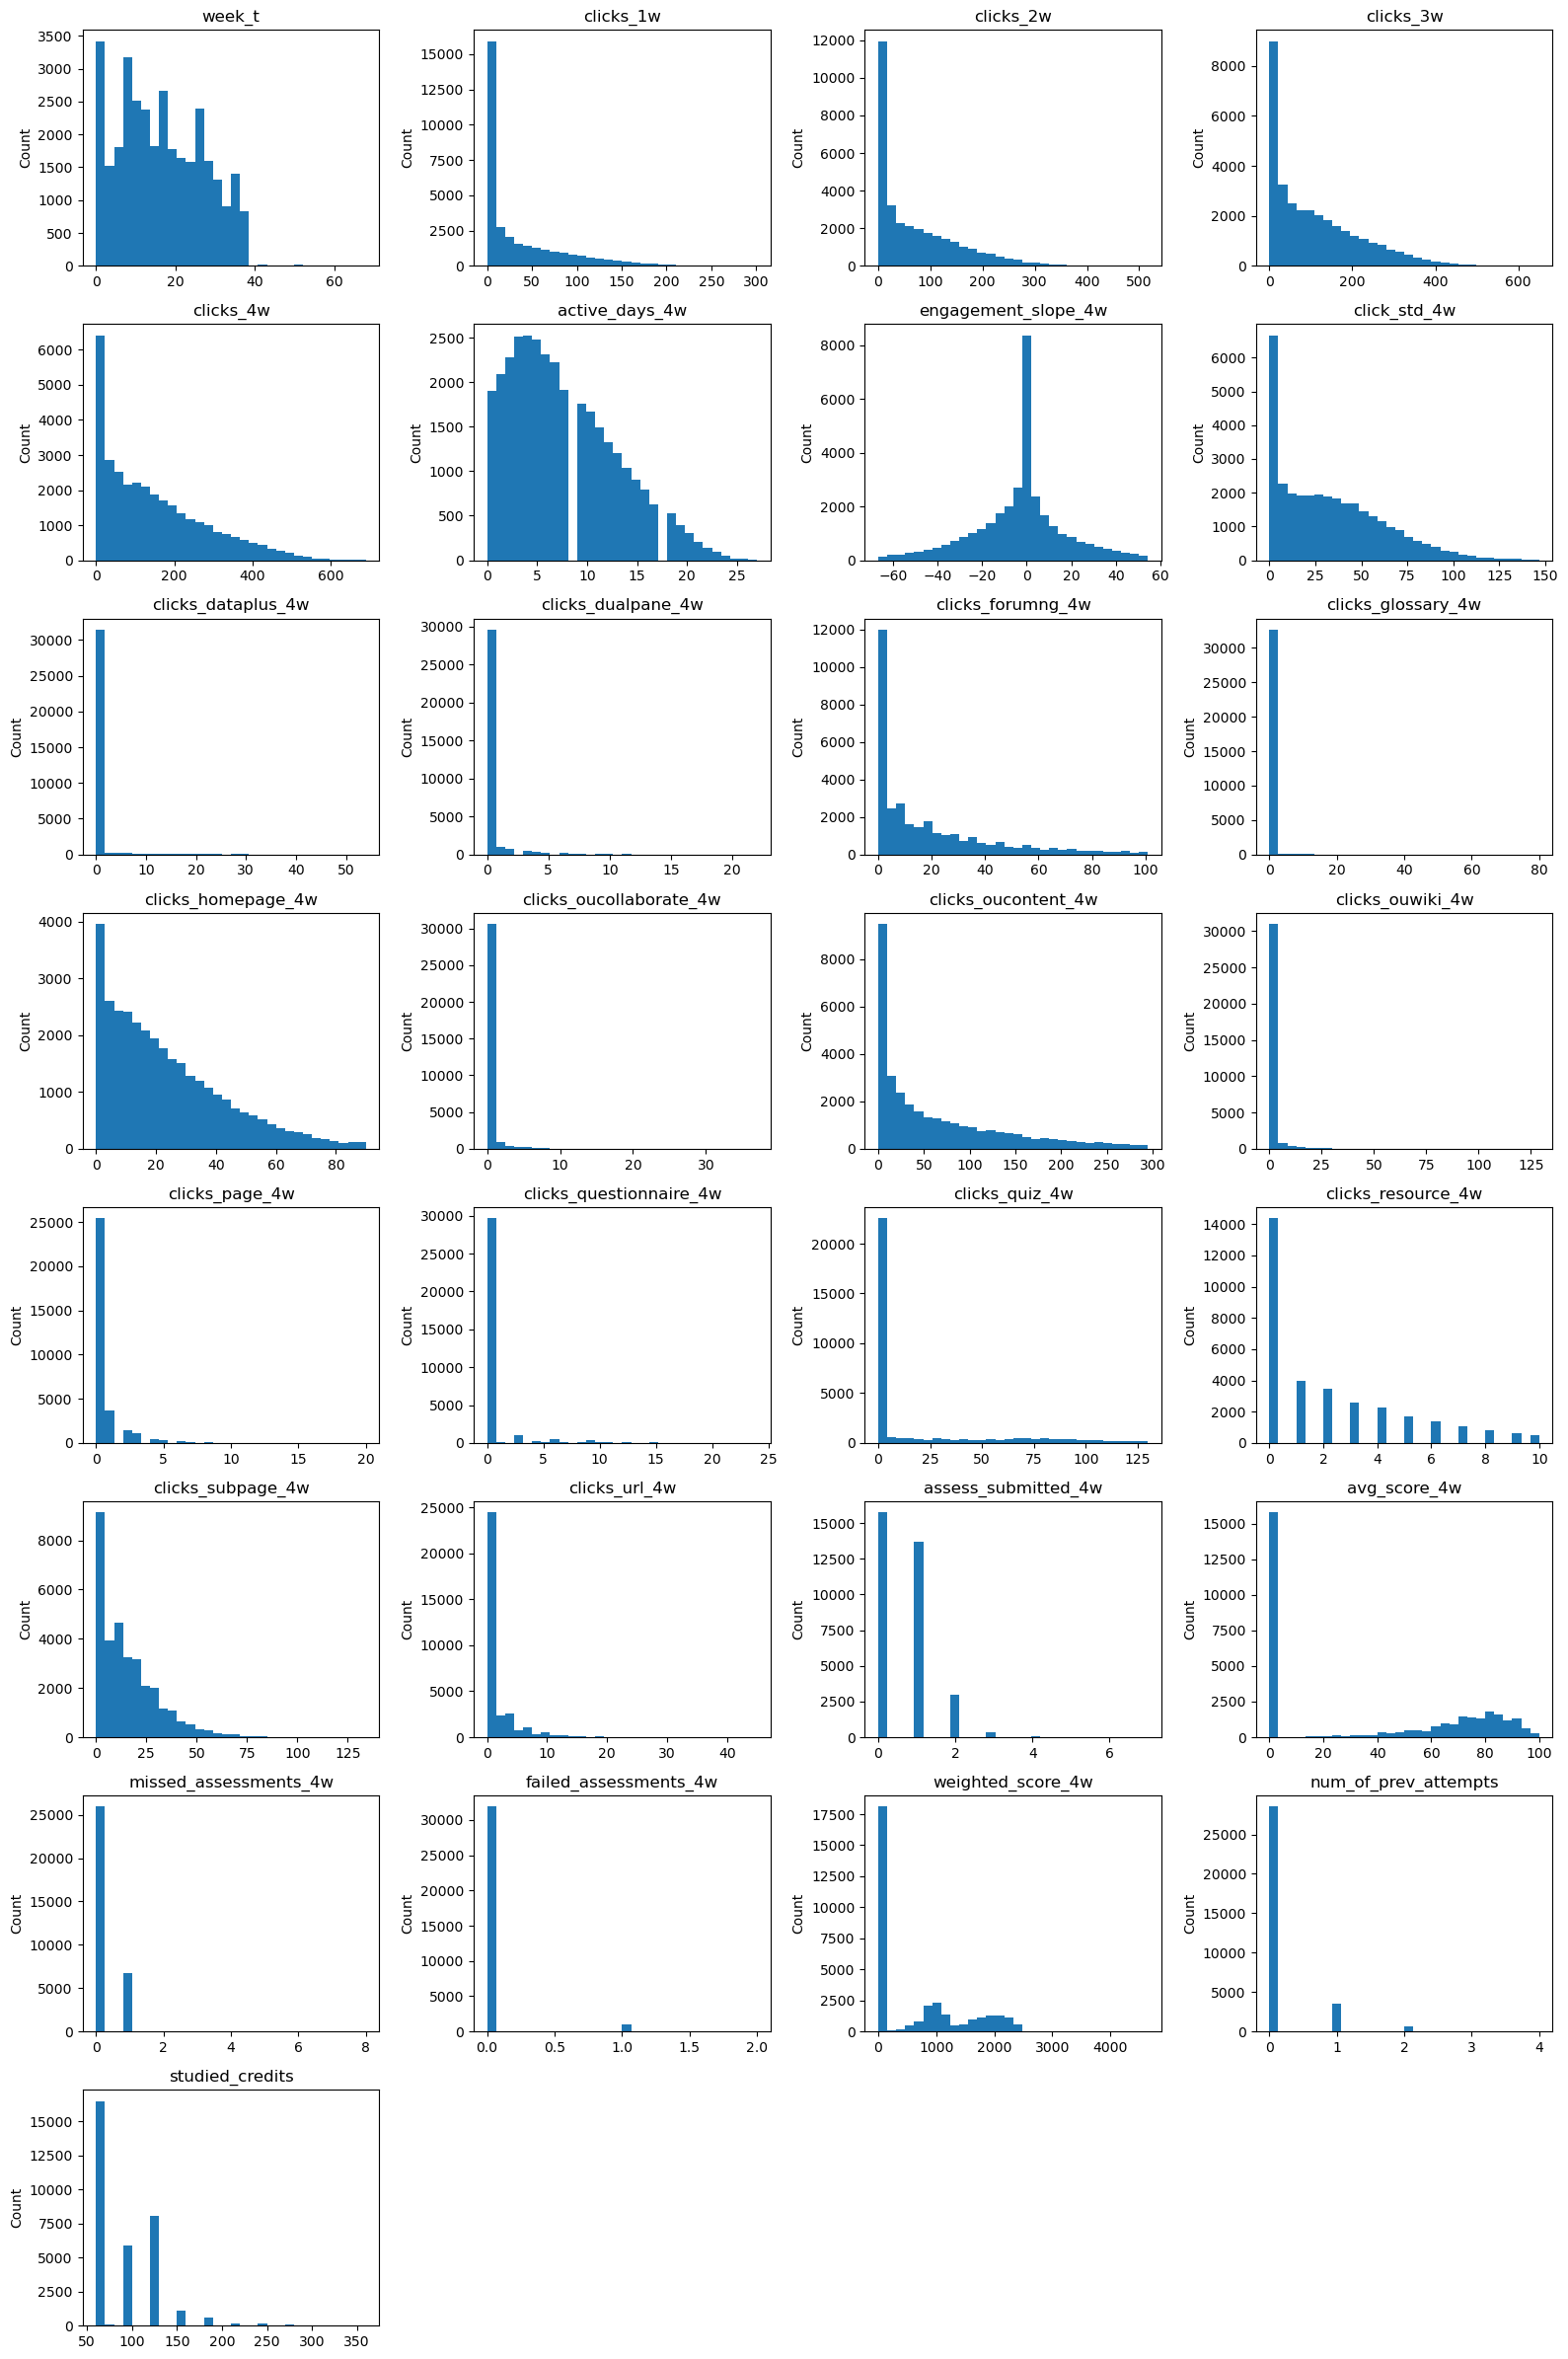

In [41]:
# number of columns per row
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

# create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

# plot histograms
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

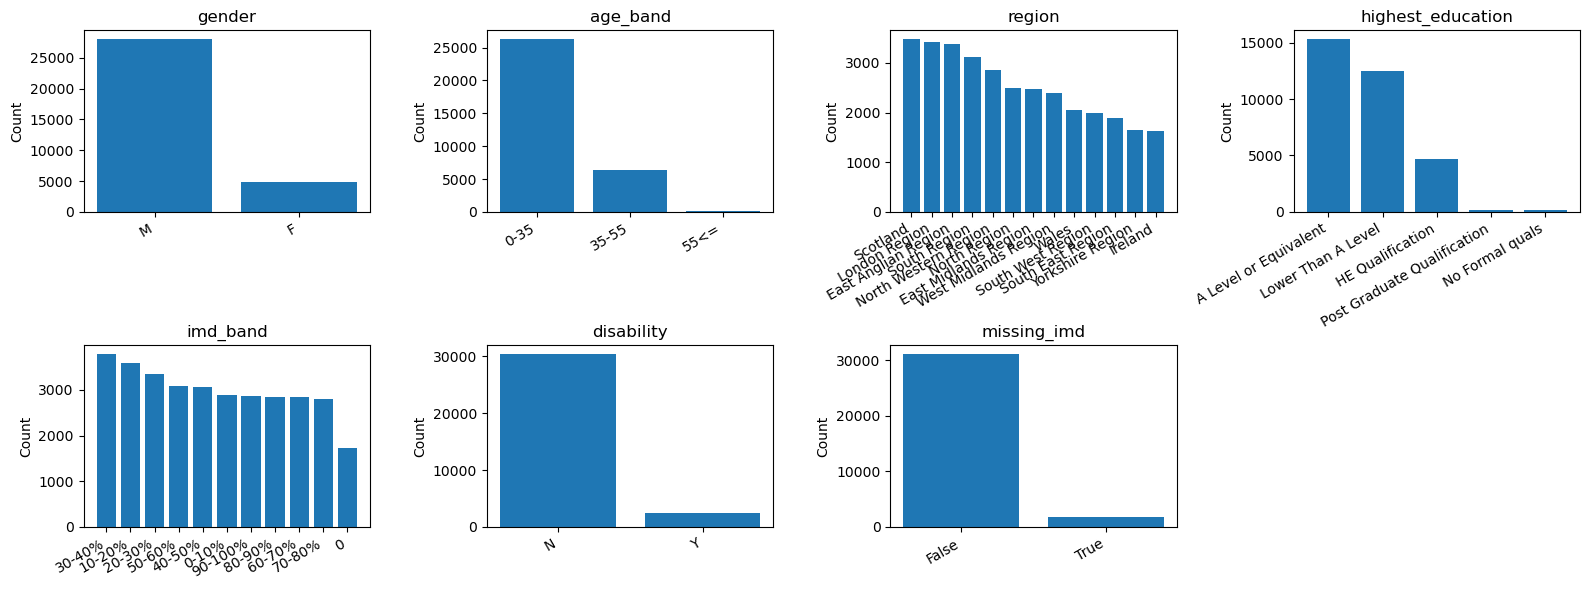

In [42]:
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(dropna=False)

    x_vals = range(len(counts))
    x_labels = ["Missing" if v != v else str(v) for v in counts.index]

    axes[i].bar(x_vals, counts.values)
    axes[i].set_title(col)
    axes[i].set_xticks(x_vals)
    axes[i].set_xticklabels(x_labels, rotation=30, ha="right")
    axes[i].set_ylabel("Count")

# remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 1.4 Encoding

Ordinal encoding was applied to ordinal features (imd_band, highest_education, age_band)

In [43]:
# Define ordinal mapping for IMD band (from most deprived to least deprived)
imd_mapping = {
    "0-10%": 1,
    "10-20%": 2,
    "20-30%": 3,
    "30-40%": 4,
    "40-50%": 5,
    "50-60%": 6,
    "60-70%": 7,
    "70-80%": 8,
    "80-90%": 9,
    "90-100%": 10,
    0: 0  # placeholder for missing/invalid values already filled as 0
}

# Apply ordinal encoding
df["imd_band"] = df["imd_band"].map(imd_mapping)

In [44]:
# Define ordinal mapping from lowest to highest education level
education_mapping = {
    "No Formal quals": 1,
    "Lower Than A Level": 2,
    "A Level or Equivalent": 3,
    "HE Qualification": 4,
    "Post Graduate Qualification": 5
}

# Apply ordinal encoding
df["highest_education"] = df["highest_education"].map(education_mapping)

In [45]:
# Define ordinal mapping from lowest to highest age band
age_mapping = {
    "0-35": 1,
    "35-55": 2,
    "55<=": 3
}

# Apply ordinal encoding
df["age_band"] = df["age_band"].map(age_mapping)

I then applied one-hot encoding to other categorical vairables.

In [46]:
from sklearn.preprocessing import OneHotEncoder

# Columns to one-hot encode
onehot_cols = ["gender", "disability", "missing_imd", "region"]

# initialize one-hot encoder (do NOT drop first category)
ohe = OneHotEncoder(
    drop=None,
    sparse_output=False,          # return dense array
    handle_unknown="ignore"
)

# fit and transform categorical variables
encoded_array = ohe.fit_transform(df[onehot_cols])

# create DataFrame with proper column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(onehot_cols),
    index=df.index
)

# drop original categorical columns and concatenate encoded ones
df = pd.concat(
    [df.drop(columns=onehot_cols), encoded_df],
    axis=1
)

df.head()

,id_student,code_module,code_presentation,week_t,days_since_start,inactivity_next_30d,clicks_1w,clicks_2w,clicks_3w,clicks_4w,...,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,26247,FFF,2013J,0,0,0,109,109,109,109,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,26247,FFF,2013J,2,14,0,144,144,253,253,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,29335,FFF,2013J,0,0,0,258,258,258,258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41,29335,FFF,2013J,37,259,0,15,43,72,123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42,29335,FFF,2013J,38,266,0,4,19,47,76,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 1.5 Scaling

I applied MinMax scaling to all numerical vairables and ordinal-encoded variables

In [47]:
all_num_cols = num_cols + ["imd_band", "highest_education", "age_band"]

from sklearn.preprocessing import MinMaxScaler

# initialize scaler
scaler = MinMaxScaler()

# fit and transform
scaled_values = scaler.fit_transform(df[all_num_cols])

# create normalized dataframe with renamed columns
df_normalized = df.copy()
df_normalized[[f"{col}_normalized" for col in all_num_cols]] = scaled_values

# drop original numerical columns
df_normalized = df_normalized.drop(columns=all_num_cols)

df_normalized.head()

,id_student,code_module,code_presentation,days_since_start,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,...,assess_submitted_4w_normalized,avg_score_4w_normalized,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized
0,26247,FFF,2013J,0,0,0,0.0,1.0,1.0,0.0,...,0.000000,0.00,0.0,0.0,0.000000,0.5,0.0,0.9,0.75,0.5
2,26247,FFF,2013J,14,0,0,0.0,1.0,1.0,0.0,...,0.142857,0.88,0.0,0.0,0.236559,0.5,0.0,0.9,0.75,0.5
4,29335,FFF,2013J,0,0,0,0.0,1.0,1.0,0.0,...,0.142857,0.87,0.0,0.0,0.000000,0.0,0.0,0.5,0.25,0.0
41,29335,FFF,2013J,259,0,0,0.0,1.0,1.0,0.0,...,0.000000,0.00,0.0,0.0,0.000000,0.0,0.0,0.5,0.25,0.0
42,29335,FFF,2013J,266,0,0,0.0,1.0,1.0,0.0,...,0.000000,0.00,0.0,0.0,0.000000,0.0,0.0,0.5,0.25,0.0


## 1.6 Distribution of target variable

The dataset is highly imbalanced, with 30,660 observations labeled as 0 (no inactivity in the next 30 days) and only 2,174 labeled as 1 (inactivity). This means the positive class represents a small minority of the data, which can cause machine learning models to bias toward predicting the majority class. 

To address this issue, I applied undersampling to the majority class by randomly sampling active cases with replacement.

This helps balance the class distribution and allows the model to better learn patterns associated with student inactivity rather than being dominated by the majority class.

(After undersampling, there are ~4374 observations in total. I double-checked with Prof. Wang that this is an acceptable sample size.)

<Axes: xlabel='inactivity_next_30d'>

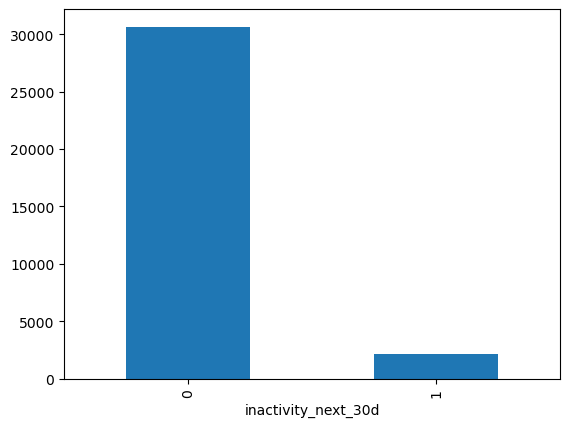

In [48]:
df_normalized[target].value_counts().plot(kind='bar')

In [49]:
df_normalized[target].value_counts()

inactivity_next_30d
0    30660
1     2174
Name: count, dtype: int64

In [ ]:
# Separate minority and majority classes
minority_class = df_normalized[df_normalized["inactivity_next_30d"] == 1]
majority_class = df_normalized[df_normalized["inactivity_next_30d"] == 0]

# Undersample majority class to 5000 samples (with replacement)
undersampled_majority = majority_class.sample(
    n=2200,
    replace=True,
    random_state=42
)

# Combine minority class with undersampled majority
df_balanced = pd.concat([minority_class, undersampled_majority], ignore_index=True)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print(df_balanced["inactivity_next_30d"].value_counts())

inactivity_next_30d
0    2200
1    2174
Name: count, dtype: int64


<Axes: xlabel='inactivity_next_30d'>

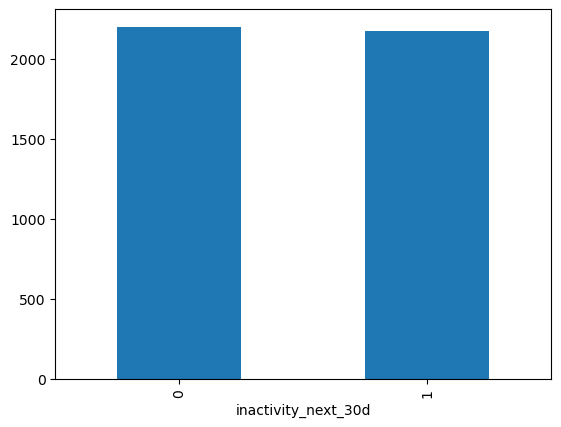

In [51]:
df_balanced[target].value_counts().plot(kind='bar')

## 1.6 Train-test split

The train and test sets are split by `id_student` to prevent data leakage caused by having multiple observations from the same student across weeks. If rows from the same student appeared in both training and testing sets, the model could implicitly learn student-specific behavior patterns, leading to overly optimistic performance estimates. Splitting by student ensures that the test set contains entirely unseen individuals, providing a more realistic evaluation of how the model will generalize to new students.

In [52]:
from sklearn.model_selection import train_test_split

# Get unique student IDs
student_ids = df_balanced["id_student"].unique()

# Split student IDs
train_ids, test_ids = train_test_split(
    student_ids,
    test_size=0.4,
    random_state=42
)

# Create train and test datasets
train_df = df_balanced[df_balanced["id_student"].isin(train_ids)]
test_df = df_balanced[df_balanced["id_student"].isin(test_ids)]

print("Number of train students:", len(train_ids))
print("Number of test students:", len(test_ids))
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Number of train students: 909
Number of test students: 607
Train shape: (2595, 57)
Test shape: (1779, 57)


<Axes: xlabel='inactivity_next_30d'>

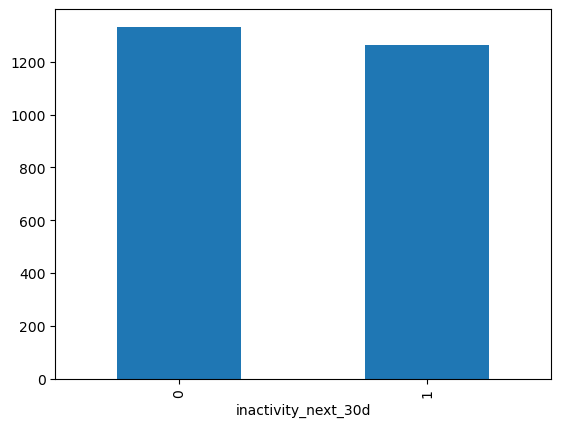

In [53]:
train_df[target].value_counts().plot(kind='bar')

<Axes: xlabel='inactivity_next_30d'>

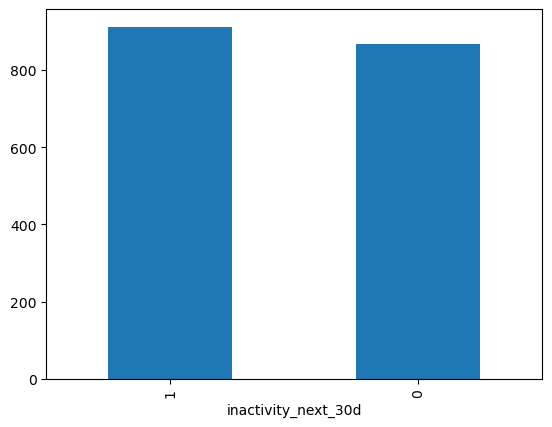

In [54]:
test_df[target].value_counts().plot(kind='bar')

In [55]:
# Drop identifier columns
train_df = train_df.drop(
    columns=["code_module", "code_presentation", "days_since_start"]
)

test_df = test_df.drop(
    columns=["code_module", "code_presentation", "days_since_start"]
)

In [56]:
train_df.head()

,id_student,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,missing_imd_False,missing_imd_True,region_East Anglian Region,...,assess_submitted_4w_normalized,avg_score_4w_normalized,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized
0,595483,1,0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,0.00,0.000,0.0,0.000000,0.0,0.0,0.7,0.25,0.0
1,438313,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000000,0.00,0.125,0.0,0.000000,0.0,0.4,0.3,0.50,0.0
2,596369,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.142857,0.88,0.000,0.0,0.473118,0.0,0.1,0.2,0.25,0.0
4,110881,0,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.142857,0.78,0.125,0.0,0.209677,0.0,0.0,0.5,0.50,0.0
6,133019,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000000,0.00,0.125,0.0,0.000000,0.0,0.0,0.4,0.25,0.0


In [57]:
train_df.to_csv("train_preprocessed_under.csv", index=False)
test_df.to_csv("test_preprocessed_under.csv", index=False)

# 2. Classification Task

In the classification task, I experimented with 3 models, logistic regression, decision tree, and gradient boosting classifiers, to predict whether a student would become inactive in the next 30 days (`inactivity_next_30d`) based on their recent behavioral and engagement features.


In [58]:
import pandas as pd

In [59]:
train = pd.read_csv("train_preprocessed_under.csv")
test = pd.read_csv("test_preprocessed_under.csv")

In [60]:
train.head()

,id_student,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,missing_imd_False,missing_imd_True,region_East Anglian Region,...,assess_submitted_4w_normalized,avg_score_4w_normalized,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized
0,595483,1,0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000000,0.00,0.000,0.0,0.000000,0.0,0.0,0.7,0.25,0.0
1,438313,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000000,0.00,0.125,0.0,0.000000,0.0,0.4,0.3,0.50,0.0
2,596369,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.142857,0.88,0.000,0.0,0.473118,0.0,0.1,0.2,0.25,0.0
3,110881,0,0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.142857,0.78,0.125,0.0,0.209677,0.0,0.0,0.5,0.50,0.0
4,133019,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000000,0.00,0.125,0.0,0.000000,0.0,0.0,0.4,0.25,0.0


In [61]:
X_train = train.drop(columns=["inactivity_next_30d", "id_student"])
y_train = train["inactivity_next_30d"]

X_test = test.drop(columns=["inactivity_next_30d", "id_student"])
y_test = test["inactivity_next_30d"]

groups = train["id_student"]

In [ ]:
# Load best models to continue analysis
import joblib

best_model_clf = joblib.load("saved_models/best_logreg_under.joblib")
best_model_dt = joblib.load("saved_models/best_decision_tree_under.joblib")
best_model_gb = joblib.load("saved_models/best_gradient_boosting_under.joblib")

## 2.1 Logistic Regression

In [62]:
# Baseline model
from sklearn.linear_model import LogisticRegression

baseline_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr.fit(X_train, y_train)

train_acc = baseline_lr.score(X_train, y_train)
test_acc   = baseline_lr.score(X_test, y_test)

print("Baseline Logistic Regression")
print("Train accuracy:", round(train_acc, 4))
print("Test accuracy:  ", round(test_acc, 4))

Baseline Logistic Regression
Train accuracy: 0.7279
Test accuracy:   0.7111


**Grid Search and Crosss Validation**

I then tunned the Logistic Regression Model using GridSearchCV. GroupKFold is used to split by `id_student` in GridSearchCV to ensure that all observations from the same student are kept within a single fold during cross-validation. Because each student may have multiple weekly records, splitting randomly at the row level would cause data leakage and lead to overly optimistic validation performance. Grouping by student ensures that the model is evaluated on entirely unseen individuals, providing a more realistic estimate of its generalization ability.

In [63]:
from sklearn.model_selection import GridSearchCV, GroupKFold

clf = LogisticRegression(
    random_state=42,
    max_iter=1000
)

hp_parameters = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

gkf = GroupKFold(n_splits=5)

grid_cv = GridSearchCV(
    estimator=clf,
    param_grid=hp_parameters,
    cv=gkf,              
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_cv.fit(X_train, y_train, groups=groups)

print("Best params:", grid_cv.best_params_)

Best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


### Model tuning:

The grid search results show that model performance is most sensitive to the regularization strength parameter **C**. Very small values of C (0.001–0.01), which imply strong regularization, lead to substantially lower mean test scores, indicating underfitting. Performance improves significantly when C increases to 0.1 and above, with the best result achieved at **C = 0.1**, suggesting that moderate regularization best captures the predictive signal. Differences between L1 and L2 penalties and the use of class weighting have only marginal effects, indicating that regularization strength plays a more critical role than penalty type or class balancing in this task.

In [64]:
results_clf = pd.DataFrame(grid_cv.cv_results_)
pd.set_option("display.max_colwidth", None)  # no truncation

print(
    results_clf[[
        "params",
        "mean_test_score",
        "rank_test_score"
    ]].sort_values("rank_test_score")    
)


                                                                              params  \
10    {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}   
8           {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}   
12            {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}   
14      {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}   
17           {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}   
19     {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}   
16           {'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}   
18     {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}   
13            {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}   
15      {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}   
9           {'C': 0.1, 'class_we

In [65]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

best_model_clf = grid_cv.best_estimator_

y_pred_clf = best_model_clf.predict(X_test)
y_proba_clf = best_model_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.74      0.65      0.69       867
           1       0.70      0.78      0.74       912

    accuracy                           0.72      1779
   macro avg       0.72      0.72      0.72      1779
weighted avg       0.72      0.72      0.72      1779



In [66]:
# Get report as dictionary
report_clf = classification_report(y_test, y_pred_clf, output_dict=True)

# Extract overall accuracy
accuracy_clf = report_clf["accuracy"]

# Extract precision and recall for each class
precision_class0_clf = report_clf["0"]["precision"]
recall_class0_clf = report_clf["0"]["recall"]

precision_class1_clf = report_clf["1"]["precision"]
recall_class1_clf = report_clf["1"]["recall"]

Test ROC-AUC: 0.7747444049859367


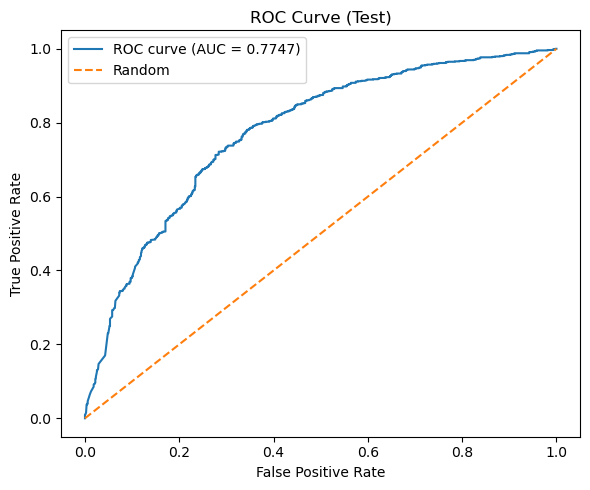

In [67]:
auc_clf = roc_auc_score(y_test, y_proba_clf)
print("Test ROC-AUC:", auc_clf)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_clf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_clf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.tight_layout()
plt.show()

### Model performance evaluation

The logistic regression model achieves moderate predictive performance, with an overall accuracy of 0.72 and a ROC-AUC of approximately 0.775, indicating reasonable discrimination between active and inactive students. 

The model performs slightly better at identifying inactive students (recall = 0.78) than active students (recall = 0.65), suggesting it is more sensitive to detecting at-risk cases. Precision values are relatively balanced across both classes, resulting in an F1-score around 0.72 overall. 

While the model provides stable and interpretable results, its ROC-AUC suggests there is room for improvement compared to more flexible models such as gradient boosting.

### Error analysis

For error analysis, I first obtain the 4 most important features for the logistic regression model according to the absoluate values of coefficients. 

Then, for each feature, I compared feature distribution of False Positive and False Negative cases against the entire sample.

In [101]:
# Error Analysis
y_pred_test = best_model_clf.predict(X_test)

# Create a result dataframe that includes:
analysis_clf = test.copy()
analysis_clf["y_true"] = y_test
analysis_clf["y_pred"] = y_pred_test

# Identify error samples (misclassified test samples)
error_clf = analysis_clf[analysis_clf["y_true"] != analysis_clf["y_pred"]].copy()

print("Total test samples:", len(analysis_clf))
print("Total error samples:", len(error_clf))
print("Test accuracy:", round((analysis_clf["y_true"] == analysis_clf["y_pred"]).mean(), 4))

print("\nExample error samples (first 10):")
display(error_clf.head(10))

Total test samples: 1779
Total error samples: 501
Test accuracy: 0.7184

Example error samples (first 10):


,id_student,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,missing_imd_False,missing_imd_True,region_East Anglian Region,...,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized,y_true,y_pred
5,604828,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.0,1.0,0.50,0.0,0,1
15,590188,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.2,0.25,0.0,0,1
18,574282,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.258065,0.0,0.1,0.8,0.50,0.5,1,0
19,468947,1,0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000,0.0,0.000000,0.0,0.0,0.3,0.50,0.0,1,0
20,559067,0,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.4,0.25,0.0,0,1
22,2472132,1,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.000,0.0,0.500000,0.0,0.0,0.0,0.75,0.5,1,0
26,572554,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.166667,0.0,0.0,0.3,0.25,0.0,1,0
31,579506,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.0,0.6,0.50,0.0,0,1
47,599816,0,0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.000,0.0,0.000000,0.0,0.2,1.0,0.75,0.0,0,1
52,371133,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.7,0.25,0.0,1,0


In [100]:
# Get coefficients from the trained logistic regression model
coef = best_model_clf.coef_[0]
feature_names = X_train.columns


coef_clf = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

# Compute absolute coefficient values to measure feature importance
coef_clf["abs_coefficient"] = coef_clf["coefficient"].abs()

# Sort features by absolute coefficient value (descending)
coef_clf_sorted = coef_clf.sort_values("abs_coefficient", ascending=False)

print(f"Top 10 features by absolute coefficient value:")
display(coef_clf_sorted.head(10))

Top 10 features by absolute coefficient value:


,feature,coefficient,abs_coefficient
25,active_days_4w_normalized,-3.389000,3.389000
21,clicks_1w_normalized,-3.143644,3.143644
5,missing_imd_False,0.646701,0.646701
43,avg_score_4w_normalized,-0.539316,0.539316
1,gender_F,0.222833,0.222833
39,clicks_resource_4w_normalized,-0.206797,0.206797
7,region_East Anglian Region,0.140589,0.140589
4,disability_Y,0.127399,0.127399
15,region_South Region,0.045110,0.045110
50,highest_education_normalized,-0.030799,0.030799


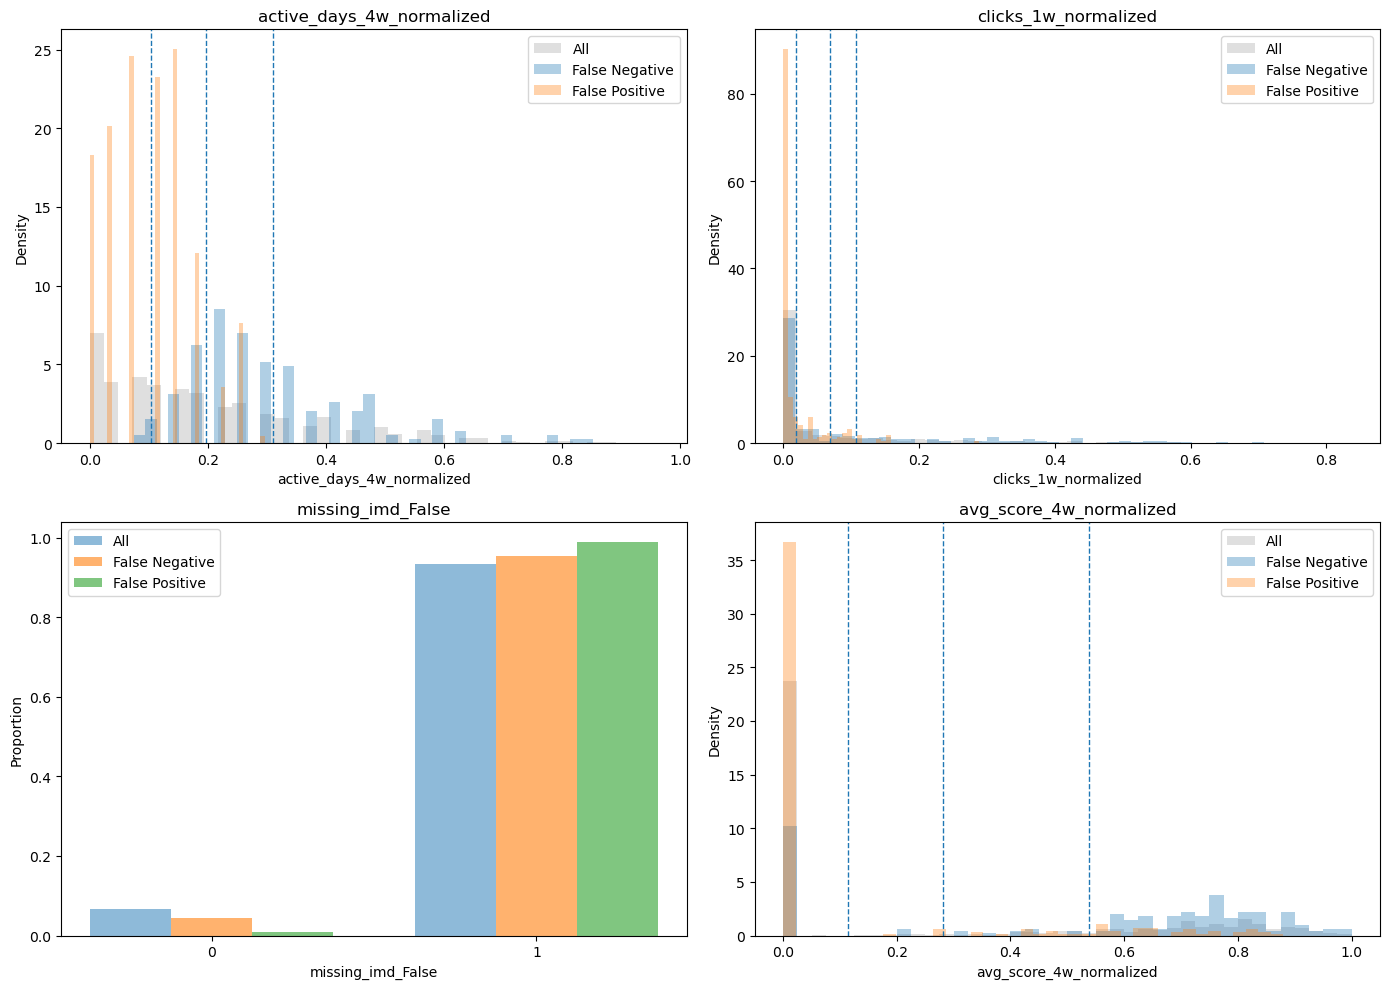

In [ ]:
import matplotlib.pyplot as plt

features = [
    "active_days_4w_normalized",
    "clicks_1w_normalized",
    "missing_imd_False",
    "avg_score_4w_normalized",
]

analysis_clf = analysis_clf.copy()

# Classify by error type

analysis_clf["error_type"] = "Correct"
analysis_clf.loc[
    (analysis_clf["y_true"] == 1) & (analysis_clf["y_pred"] == 0),
    "error_type"
] = "False Negative"
analysis_clf.loc[
    (analysis_clf["y_true"] == 0) & (analysis_clf["y_pred"] == 1),
    "error_type"
] = "False Positive"


# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    whole = analysis_clf[col].dropna()
    fn = analysis_clf.loc[analysis_clf["error_type"] == "False Negative", col].dropna()
    fp = analysis_clf.loc[analysis_clf["error_type"] == "False Positive", col].dropna()

    unique_vals = np.sort(whole.unique())

    # Binary variable
    if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, False, True}):
        whole_counts = whole.astype(int).value_counts().reindex([0, 1], fill_value=0)
        fn_counts = fn.astype(int).value_counts().reindex([0, 1], fill_value=0)
        fp_counts = fp.astype(int).value_counts().reindex([0, 1], fill_value=0)

        whole_prop = whole_counts / whole_counts.sum() if whole_counts.sum() else whole_counts
        fn_prop = fn_counts / fn_counts.sum() if fn_counts.sum() else fn_counts
        fp_prop = fp_counts / fp_counts.sum() if fp_counts.sum() else fp_counts

        x = np.array([0, 1])
        width = 0.25

        ax.bar(x - width, whole_prop.values, width=width, alpha=0.5, label="All")
        ax.bar(x, fn_prop.values, width=width, alpha=0.6, label="False Negative")
        ax.bar(x + width, fp_prop.values, width=width, alpha=0.6, label="False Positive")

        ax.set_xticks([0, 1])
        ax.set_ylabel("Proportion")

    # Numeric 
    else:
        ax.hist(whole, bins=40, density=True, alpha=0.25, color = "grey", label="All")
        ax.hist(fn, bins=40, density=True, alpha=0.35, label="False Negative")
        ax.hist(fp, bins=40, density=True, alpha=0.35, label="False Positive")

        # Mean lines
        if len(whole) > 0:
            ax.axvline(whole.mean(), linestyle="--", linewidth=1)
        if len(fn) > 0:
            ax.axvline(fn.mean(), linestyle="--", linewidth=1)
        if len(fp) > 0:
            ax.axvline(fp.mean(), linestyle="--", linewidth=1)

        ax.set_ylabel("Density")

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

**Findings**

The errors appear to occur primarily in regions where engagement levels are low to moderate and the class separation is ambiguous. For **clicks_1w_normalized** and **active_days_4w_normalized**, both false positives and false negatives cluster around small values, suggesting that borderline engagement patterns are difficult to distinguish. In particular, some students with very low recent clicks are still active (false positives), while others with moderate engagement still become inactive (false negatives). The distribution of **avg_score_4w_normalized** shows that some students with relatively strong recent scores are misclassified, indicating that performance alone does not fully capture dropout risk. Overall, the errors likely stem from overlapping feature distributions and complex interactions among engagement and performance variables that are not perfectly separable by the model.

## 2.2 Decision Tree

In [69]:
# Baseline model
from sklearn.tree import DecisionTreeClassifier

baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)

train_acc_dt = baseline_dt.score(X_train, y_train)
test_acc_dt   = baseline_dt.score(X_test, y_test)

print("Baseline Logistic Regression")
print("Train accuracy:", round(train_acc_dt, 4))
print("Test accuracy:  ", round(test_acc_dt, 4))

Baseline Logistic Regression
Train accuracy: 1.0
Test accuracy:   0.6599


The baseline decision tree model shows clear signs of overfitting, as it achieves nearly perfect training accuracy (1.0) but performs much worse on the test set (0.6599), indicating that it memorized the training data rather than learning generalizable patterns. This large gap between train and test accuracy suggests high variance and poor generalization. This issu is later addressed by tuning hyperparameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`, which constrain the tree’s complexity and help reduce overfitting, leading to more stable performance on unseen data.

In [70]:
dt = DecisionTreeClassifier(random_state=42)

hp_parameters = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

gkf = GroupKFold(n_splits=5)

grid_cv_dt = GridSearchCV(
    estimator=dt,
    param_grid=hp_parameters,
    cv=gkf,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_cv_dt.fit(X_train, y_train, groups = groups)
print("Best params:", grid_cv_dt.best_params_)

Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}


### Model tuning

The grid search results show that decision tree performance is highly sensitive to tree complexity parameters. The best-performing models consistently use a shallow tree with **max_depth = 5** and **min_samples_leaf = 5**, suggesting that controlling model complexity is critical for generalization. In contrast, deeper trees with unlimited depth and very small leaf sizes perform substantially worse, indicating severe overfitting. Differences in splitting criteria (gini, entropy, log_loss) and class weighting have relatively minor effects compared to depth and leaf size. Overall, moderate pruning and regularization through shallow depth produce the most stable and highest-performing decision tree models.

In [71]:
results_dt = pd.DataFrame(grid_cv_dt.cv_results_)
pd.set_option("display.max_colwidth", None)  # no truncation

print(
    results_dt[[
        "params",
        "mean_test_score",
        "rank_test_score"
    ]].sort_values("rank_test_score")    
)

                                                                                                                                               params  \
107                 {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}   
105                  {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5}   
104                  {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}   
106                 {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 10}   
827           {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}   
...                                                                               

In [72]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

best_model_dt = grid_cv_dt.best_estimator_

y_pred_dt = best_model_dt.predict(X_test)
y_proba_dt = best_model_dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70       867
           1       0.71      0.76      0.73       912

    accuracy                           0.72      1779
   macro avg       0.72      0.72      0.72      1779
weighted avg       0.72      0.72      0.72      1779



In [73]:
# Get report as dictionary
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)

# Extract overall accuracy
accuracy_dt = report_dt["accuracy"]

# Extract precision and recall for each class
precision_class0_dt = report_dt["0"]["precision"]
recall_class0_dt = report_dt["0"]["recall"]

precision_class1_dt = report_dt["1"]["precision"]
recall_class1_dt = report_dt["1"]["recall"]

Test ROC-AUC: 0.7680914729152755


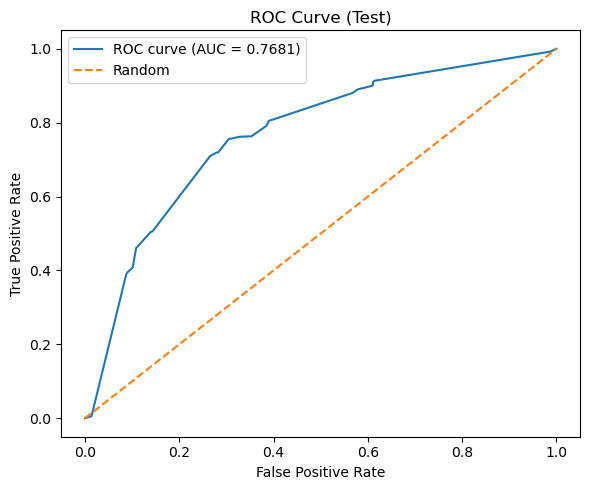

In [74]:
auc_dt = roc_auc_score(y_test, y_proba_dt)
print("Test ROC-AUC:", auc_dt)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_dt:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.tight_layout()
plt.show()

### Model performance evaluation

The decision tree classifier achieves moderate predictive performance, with an overall accuracy of 0.72 and a ROC-AUC of approximately 0.768, indicating reasonable but not strong discriminative ability. The model performs slightly better at identifying inactive students (recall = 0.76) than active students (recall = 0.67), suggesting greater sensitivity to at-risk cases. Precision and F1-scores are relatively balanced across both classes, showing stable classification performance. However, the ROC-AUC being slightly lower than logistic regression indicates somewhat weaker ranking performance across decision thresholds.

### Error analysis

For error analysis, I first obtain the 4 of the most important features for the decision tree according to the decision tree visualization. 

Then, for each feature, I compared feature distribution of False Positive and False Negative cases against the entire sample.

In [108]:
# Error Analysis
y_pred_test = best_model_dt.predict(X_test)

# Create a result dataframe that includes:
analysis_df = test.copy()
analysis_df["y_true"] = y_test
analysis_df["y_pred"] = y_pred_test

# Identify error samples (misclassified test samples)
error_samples = analysis_df[analysis_df["y_true"] != analysis_df["y_pred"]].copy()

print("Total test samples:", len(analysis_df))
print("Total error samples:", len(error_samples))
print("Test accuracy:", round((analysis_df["y_true"] == analysis_df["y_pred"]).mean(), 4))

print("\nExample error samples (first 10):")
display(error_samples.head(10))

Total test samples: 1779
Total error samples: 502
Test accuracy: 0.7178

Example error samples (first 10):


,id_student,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,missing_imd_False,missing_imd_True,region_East Anglian Region,...,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized,y_true,y_pred
6,581563,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.2,0.2,0.50,0.0,1,0
8,605269,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.2,0.5,0.50,0.0,1,0
13,573901,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.161290,0.0,0.0,0.9,0.75,0.0,0,1
14,598353,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.3,0.5,0.75,0.5,1,0
15,590188,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.2,0.25,0.0,0,1
16,394239,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.188172,0.0,0.0,0.1,0.50,0.5,0,1
18,574282,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.258065,0.0,0.1,0.8,0.50,0.5,1,0
19,468947,1,0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000,0.0,0.000000,0.0,0.0,0.3,0.50,0.0,1,0
20,559067,0,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.4,0.25,0.0,0,1
26,572554,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.166667,0.0,0.0,0.3,0.25,0.0,1,0


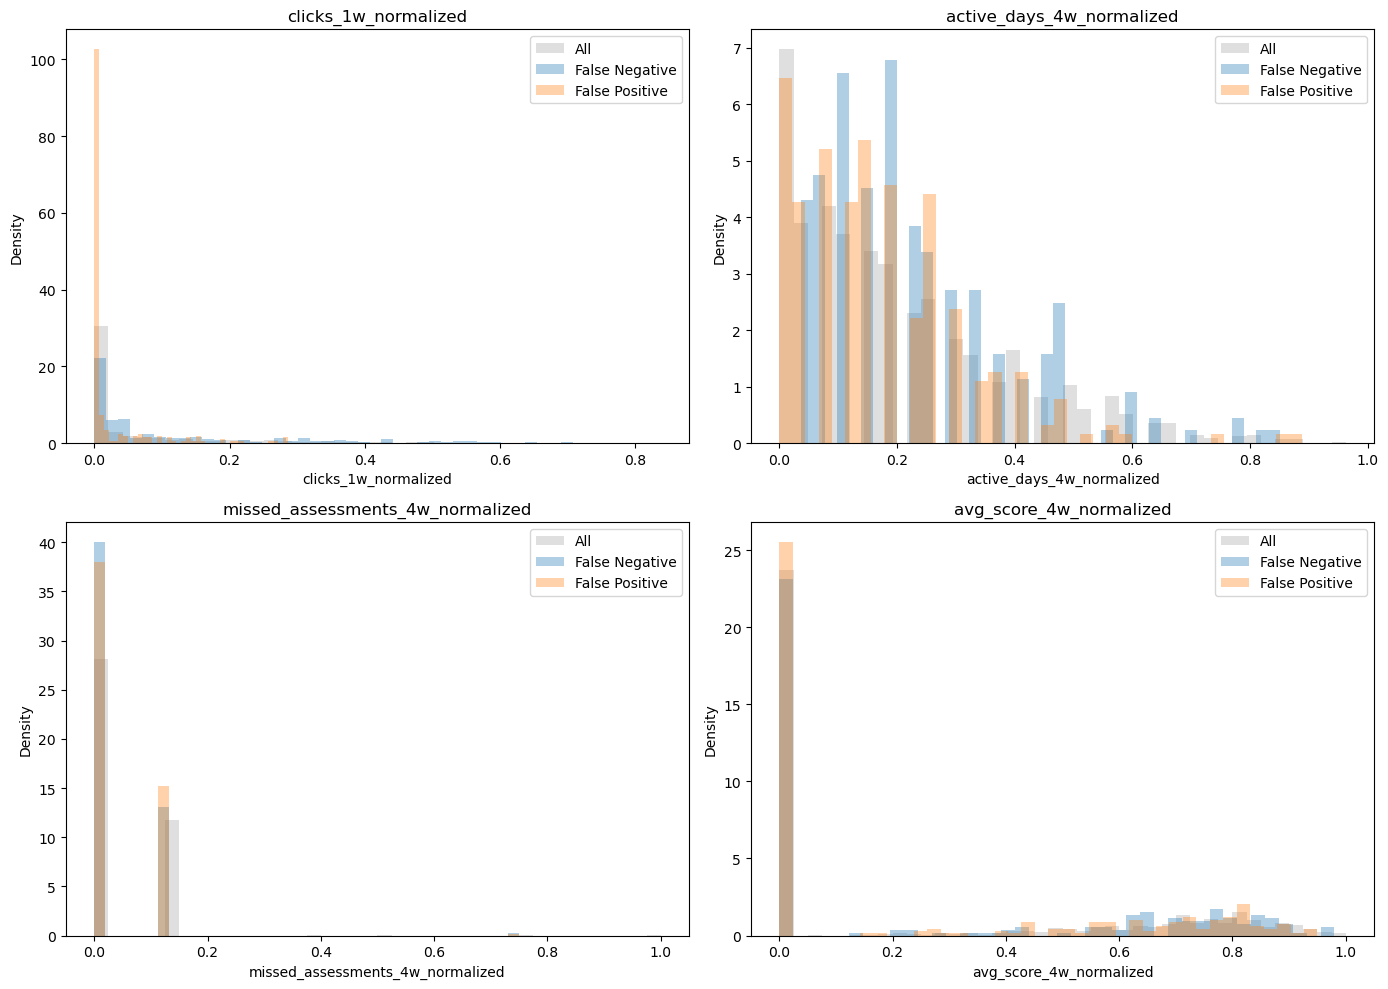

In [111]:
analysis_df = analysis_df.copy()

analysis_df["error_type"] = "Correct"
analysis_df.loc[(analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0), "error_type"] = "False Negative"
analysis_df.loc[(analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1), "error_type"] = "False Positive"

import matplotlib.pyplot as plt

features = [
    "clicks_1w_normalized",
    "active_days_4w_normalized",
    "missed_assessments_4w_normalized",
    "avg_score_4w_normalized"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

bins = 40

for ax, col in zip(axes, features):
    all_vals = analysis_df[col].dropna()
    fn_vals  = analysis_df.loc[analysis_df["error_type"] == "False Negative", col].dropna()
    fp_vals  = analysis_df.loc[analysis_df["error_type"] == "False Positive", col].dropna()

    ax.hist(all_vals, bins=bins, density=True, alpha=0.25, color = "grey", label="All")
    ax.hist(fn_vals,  bins=bins, density=True, alpha=0.35, label="False Negative")
    ax.hist(fp_vals,  bins=bins, density=True, alpha=0.35, label="False Positive")

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

**Findings**

The misclassification errors appear to arise mainly from substantial overlap between false positives, false negatives, and the overall sample distributions across all four features. For **clicks_1w_normalized** and **active_days_4w_normalized**, both false negatives and false positives cluster in low-to-moderate engagement ranges, where inactive and active students are less clearly separable. Similarly, the distribution of **missed_assessments_4w_normalized** shows overlap, suggesting that moderate short-term assessment behavior does not provide a sharp decision boundary. In the case of **avg_score_4w_normalized**, some students with relatively high recent scores are still misclassified, indicating that performance alone cannot fully distinguish inactivity risk. Overall, the errors likely stem from borderline engagement patterns and nonlinear interactions that a single decision tree may not fully capture.

### Visualization of decision tree

In [76]:
# Visualizing the decision tree
import graphviz
from sklearn.tree import export_graphviz

# visualize the best-performing decision tree
dot_tree = export_graphviz(
    best_model_dt,
    out_file=None,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    special_characters=True
)

src_tree = graphviz.Source(dot_tree)
src_tree.render(
    filename="decision_tree_viz_under",
    directory="",
    format="png",
    cleanup=True)

'decision_tree_viz_under.png'

In [77]:
dot_tree_top2 = export_graphviz(best_model_dt,
                out_file=None,
                feature_names=X_train.columns,
                class_names=['0', '1'],
                filled=True,
                rounded=True,
                special_characters=True,
                max_depth=2)
graph_top2 = graphviz.Source(dot_tree_top2)
graph_top2.render(
    filename="decision_tree_top2_viz_under",
    directory="",
    format="png",
    cleanup=True)

'decision_tree_top2_viz_under.png'

The decision tree shows that the most important predictor of next-30-day inactivity is **very recent engagement**, as `clicks_1w_normalized` appears at the root node. This indicates that the number of clicks in the *last week* is the strongest signal: students with very low activity in the previous week are immediately separated into a higher-risk branch. Subsequent splits rely on short-term engagement patterns such as `active_days_4w_normalized`, `clicks_3w_normalized`, and homepage interactions, suggesting that consistent activity over the past few weeks helps distinguish persistently engaged students from those trending toward disengagement. In summary, the tree structure confirms that **short-term behavioral momentum**, rather than static characteristics, is the dominant driver of weekly inactivity prediction.

**Visualizations are saved in the repo

## 2.3 Gradient Boosting Classifier

In [78]:
# Baseline model
from sklearn.ensemble import GradientBoostingClassifier

baseline_gb = GradientBoostingClassifier(
    random_state=42
)
baseline_gb.fit(X_train, y_train)

train_acc_gb = baseline_gb.score(X_train, y_train)
test_acc_gb   = baseline_gb.score(X_test, y_test)

print("Baseline Logistic Regression")
print("Train accuracy:", round(train_acc_gb, 4))
print("Test accuracy:  ", round(test_acc_gb, 4))

Baseline Logistic Regression
Train accuracy: 0.8362
Test accuracy:   0.7476


In [79]:
from sklearn.model_selection import GridSearchCV, GroupKFold

gb = GradientBoostingClassifier(random_state=42)

hp_parameters = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "max_features": [None, "sqrt"]
}

gkf = GroupKFold(n_splits=5)

grid_cv_gb = GridSearchCV(
    estimator=gb,
    param_grid=hp_parameters,
    cv=gkf,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
    verbose=3
)

grid_cv_gb.fit(X_train, y_train, groups=groups)

print("Best params:", grid_cv_gb.best_params_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[CV 4/5] END learning_rate=0.01, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8;, score=(train=0.849, test=0.836) total time=   0.8s
[CV 1/5] END learning_rate=0.01, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8;, score=(train=0.857, test=0.803) total time=   0.8s
[CV 2/5] END learning_rate=0.01, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8;, score=(train=0.846, test=0.832) total time=   0.8s
[CV 3/5] END learning_rate=0.01, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8;, score=(train=0.847, test=0.841) total time=   0.9s
[CV 5/5] END learning_rate=0.01, max_depth=3, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.8;, score=(train=0.857, test=0.773) 

### Model tuning

The grid search results indicate that the gradient boosting model performs best with a **moderate learning rate of 0.05**, **shallow trees (max_depth = 3)**, and **200 estimators**, achieving the highest mean test score of approximately 0.831. This suggests that controlling tree depth and learning rate is crucial for balancing bias and variance. Configurations with deeper trees (max_depth = 5) and larger numbers of estimators generally perform worse, likely due to increased model complexity and overfitting. The effects of `max_features`, `min_samples_split`, and `subsample` appear relatively minor compared to learning rate and tree depth. Overall, the results show that a moderately regularized boosting setup yields the strongest generalization performance.


In [80]:
results_gb = pd.DataFrame(grid_cv_gb.cv_results_)
pd.set_option("display.max_colwidth", None)  # no truncation

print(
    results_gb[[
        "params",
        "mean_test_score",
        "rank_test_score"
    ]].sort_values("rank_test_score")    
)

                                                                                                                                                      params  \
327      {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}   
399    {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}   
405   {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 1.0}   
428  {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 200, 'subsample': 0.8}   
422  {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}   
..                                      

In [81]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

best_model_gb = grid_cv_gb.best_estimator_

y_pred_gb = best_model_gb.predict(X_test)
y_proba_gb = best_model_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       867
           1       0.76      0.75      0.75       912

    accuracy                           0.75      1779
   macro avg       0.75      0.75      0.75      1779
weighted avg       0.75      0.75      0.75      1779



In [82]:
# Get report as dictionary
report_gb = classification_report(y_test, y_pred_gb, output_dict=True)

# Extract overall accuracy
accuracy_gb = report_gb["accuracy"]

# Extract precision and recall for each class
precision_class0_gb = report_gb["0"]["precision"]
recall_class0_gb = report_gb["0"]["recall"]

precision_class1_gb = report_gb["1"]["precision"]
recall_class1_gb = report_gb["1"]["recall"]

Test ROC-AUC: 0.8210208877152512


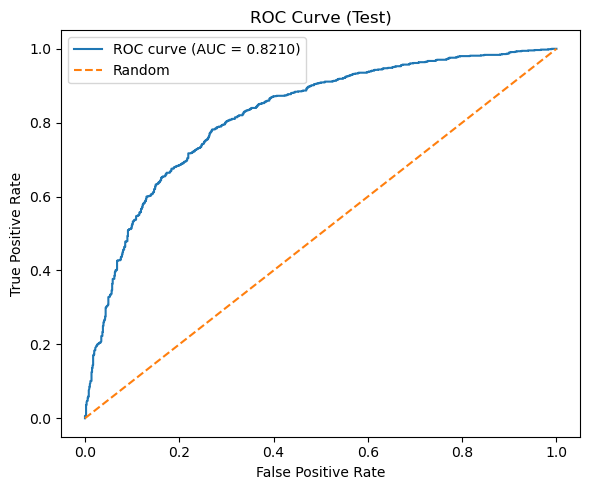

In [83]:
auc_gb = roc_auc_score(y_test, y_proba_gb)
print("Test ROC-AUC:", auc_gb)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_gb)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_gb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.tight_layout()
plt.show()

### Model performance evaluation

The gradient boosting model demonstrates the strongest overall performance among the tested models, achieving an accuracy of 0.75 and a ROC-AUC of approximately 0.821, indicating strong discriminative ability between active and inactive students. Precision and recall are well balanced across both classes, with F1-scores around 0.74–0.75, showing stable classification performance. The relatively high ROC-AUC suggests that the model effectively ranks students by inactivity risk across different decision thresholds. Compared to logistic regression and decision tree models, gradient boosting provides better generalization and captures more complex engagement patterns. Overall, it is the most effective model for predicting student inactivity in this dataset.

In [84]:
# save the best models locally
import joblib
from pathlib import Path

out_dir = Path("saved_models")
out_dir.mkdir(exist_ok=True)

# Example: save your best estimators
joblib.dump(best_model_clf, out_dir / "best_logreg_under.joblib")
joblib.dump(best_model_dt, out_dir / "best_decision_tree_under.joblib")
joblib.dump(best_model_gb, out_dir / "best_gradient_boosting_under.joblib")

print("Saved to:", out_dir.resolve())

Saved to: /Users/yuqiuyi/Desktop/30100 PJ/saved_models


### Error analysis

For error analysis, I first obtain the 4 most important features for the Gradient Boosting model. 

Then, for each feature, I compared feature distribution of False Positive and False Negative cases against the entire sample.

In [85]:
# Error Analysis
y_pred_test = best_model_gb.predict(X_test)

# Create a result dataframe that includes:
analysis_df = test.copy()
analysis_df["y_true"] = y_test
analysis_df["y_pred"] = y_pred_test

# Identify error samples (misclassified test samples)
error_samples = analysis_df[analysis_df["y_true"] != analysis_df["y_pred"]].copy()

print("Total test samples:", len(analysis_df))
print("Total error samples:", len(error_samples))
print("Test accuracy:", round((analysis_df["y_true"] == analysis_df["y_pred"]).mean(), 4))

print("\nExample error samples (first 10):")
display(error_samples.head(10))

Total test samples: 1779
Total error samples: 448
Test accuracy: 0.7482

Example error samples (first 10):


,id_student,inactivity_next_30d,clicks_repeatactivity_4w,gender_F,gender_M,disability_N,disability_Y,missing_imd_False,missing_imd_True,region_East Anglian Region,...,missed_assessments_4w_normalized,failed_assessments_4w_normalized,weighted_score_4w_normalized,num_of_prev_attempts_normalized,studied_credits_normalized,imd_band_normalized,highest_education_normalized,age_band_normalized,y_true,y_pred
6,581563,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.2,0.2,0.50,0.0,1,0
8,605269,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.2,0.5,0.50,0.0,1,0
13,573901,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.161290,0.0,0.0,0.9,0.75,0.0,0,1
14,598353,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.000000,0.0,0.3,0.5,0.75,0.5,1,0
15,590188,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.2,0.25,0.0,0,1
16,394239,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.125,0.0,0.188172,0.0,0.0,0.1,0.50,0.5,0,1
18,574282,1,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.000,0.0,0.258065,0.0,0.1,0.8,0.50,0.5,1,0
19,468947,1,0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.000,0.0,0.000000,0.0,0.0,0.3,0.50,0.0,1,0
20,559067,0,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.125,0.0,0.000000,0.0,0.0,0.4,0.25,0.0,0,1
22,2472132,1,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.000,0.0,0.500000,0.0,0.0,0.0,0.75,0.5,1,0


In [ ]:
# Get feature names from training data
feature_names = X_train.columns

# Extract importance values
importances = best_model_gb.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort descending
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Show top 10
importance_df.head(10)

,feature,importance
0,clicks_1w_normalized,0.397129
1,week_t_normalized,0.109667
2,active_days_4w_normalized,0.061553
3,clicks_2w_normalized,0.058990
4,missed_assessments_4w_normalized,0.042805
5,studied_credits_normalized,0.042427
6,clicks_homepage_4w_normalized,0.036877
7,avg_score_4w_normalized,0.035291
8,engagement_slope_4w_normalized,0.025468
9,weighted_score_4w_normalized,0.023636


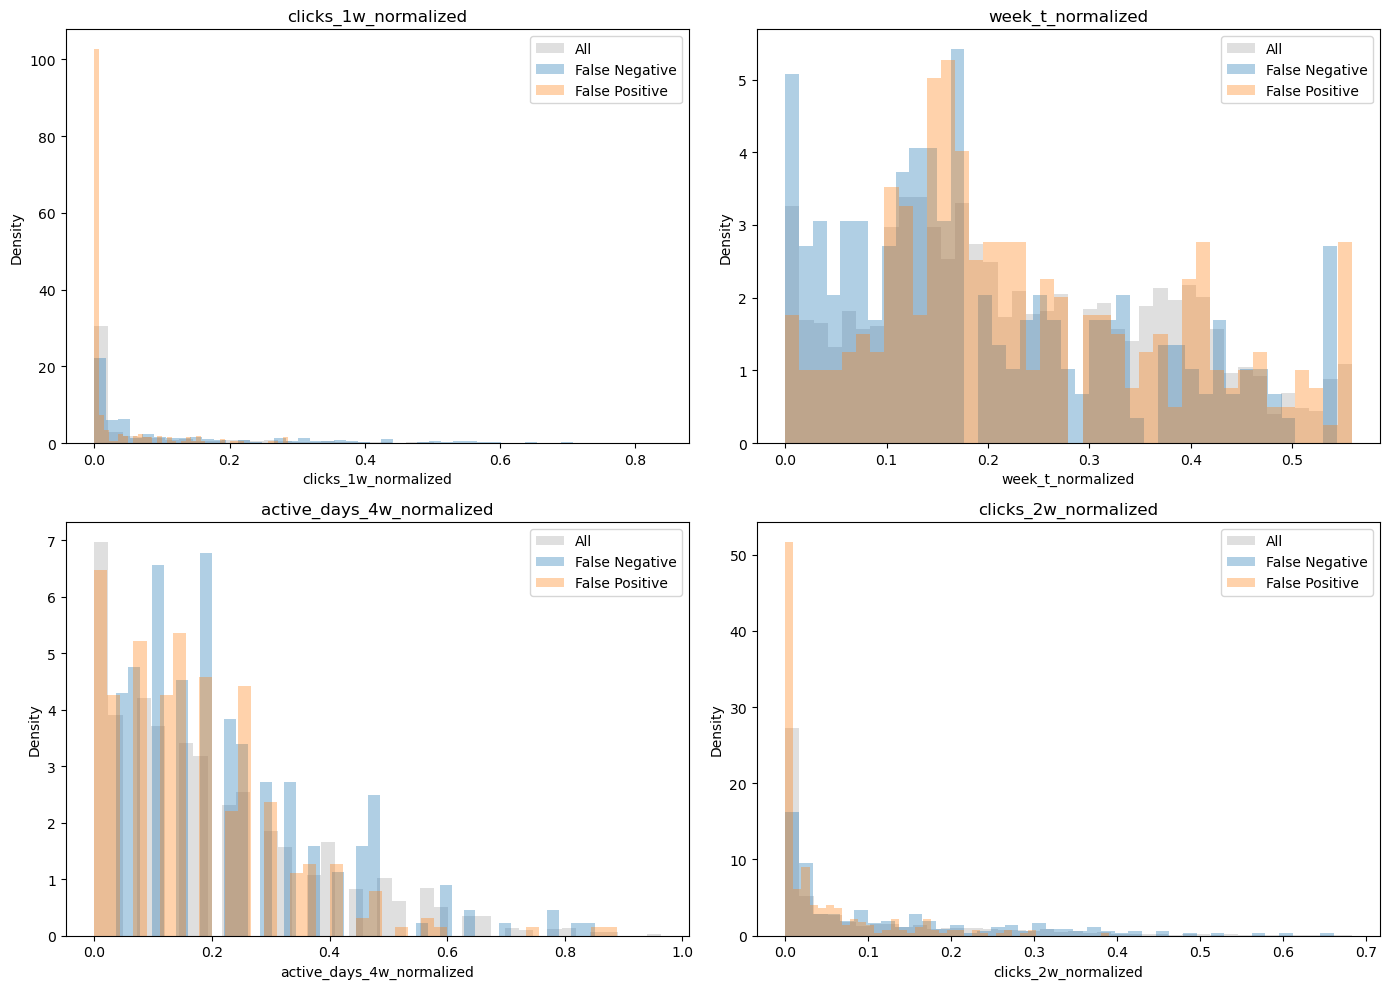

In [115]:
analysis_df = analysis_df.copy()

analysis_df["error_type"] = "Correct"
analysis_df.loc[(analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0), "error_type"] = "False Negative"
analysis_df.loc[(analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1), "error_type"] = "False Positive"

import matplotlib.pyplot as plt

features = [
    "clicks_1w_normalized",
    "week_t_normalized",
    "active_days_4w_normalized",
    "clicks_2w_normalized"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

bins = 40

for ax, col in zip(axes, features):
    all_vals = analysis_df[col].dropna()
    fn_vals  = analysis_df.loc[analysis_df["error_type"] == "False Negative", col].dropna()
    fp_vals  = analysis_df.loc[analysis_df["error_type"] == "False Positive", col].dropna()

    ax.hist(all_vals, bins=bins, density=True, alpha=0.25, color = "grey", label="All")
    ax.hist(fn_vals,  bins=bins, density=True, alpha=0.35, label="False Negative")
    ax.hist(fp_vals,  bins=bins, density=True, alpha=0.35, label="False Positive")

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

The misclassification errors in the Gradient Boosting model appear to occur mainly in regions where engagement levels are very low and heavily concentrated near zero, especially for **clicks_1w_normalized** and **clicks_2w_normalized**. Both false positives and false negatives overlap substantially with the overall sample in these low-value ranges, indicating that extremely sparse short-term engagement makes it difficult to distinguish truly inactive students from temporarily quiet but still active ones. For **active_days_4w_normalized**, misclassified cases cluster around low-to-moderate values, suggesting ambiguity in borderline engagement behavior. The distribution of **week_t_normalized** shows broad overlap across all groups, implying that course timing alone does not clearly separate inactivity risk. Overall, the errors likely arise from overlapping behavioral patterns in low-engagement regions and subtle nonlinear interactions that even the ensemble model cannot fully disentangle.

## 2.4 Model Comparison

In [86]:
import joblib

best_model = joblib.load("saved_models/best_logreg_under.joblib")
best_dt_model = joblib.load("saved_models/best_decision_tree_under.joblib")
best_gb_model = joblib.load("saved_models/best_gradient_boosting_under.joblib")

In [86]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Gradient Boosting"],
    "Accuracy": [accuracy_clf, accuracy_dt, accuracy_gb],
    "Precision_Class0": [precision_class0_clf, precision_class0_dt, precision_class0_gb],
    "Recall_Class0": [recall_class0_clf, recall_class0_dt, recall_class0_gb],
    "Precision_Class1": [precision_class1_clf, precision_class1_dt, precision_class1_gb],
    "Recall_Class1": [recall_class1_clf, recall_class1_dt, recall_class1_gb],
    "ROC_AUC": [auc_clf, auc_dt, auc_gb]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision_Class0,Recall_Class0,Precision_Class1,Recall_Class1,ROC_AUC
0,Logistic Regression,0.7184,0.7395,0.6517,0.7025,0.7818,0.7747
1,Decision Tree,0.7178,0.7284,0.6713,0.7092,0.7621,0.7681
2,Gradient Boosting,0.7482,0.7405,0.7439,0.7555,0.7522,0.8210


Among the three models, **Gradient Boosting** demonstrates the strongest overall performance, achieving the highest accuracy (0.7482) and the highest ROC-AUC (0.8210), indicating superior discriminative ability. It also maintains a well-balanced precision and recall across both classes, suggesting stable and consistent classification performance.

In comparison, **Logistic Regression** and **Decision Tree** achieve similar accuracy levels (around 0.718), but both have lower ROC-AUC scores, indicating weaker ranking performance. Logistic Regression performs slightly better at identifying inactive students (higher recall for Class 1), while Decision Tree shows slightly more balanced recall between the two classes.

Gradient Boosting performs best because it sequentially combines multiple shallow decision trees, allowing each new tree to correct the errors of previous ones and capture complex nonlinear relationships in the data. This combination of flexibility and controlled regularization enables the model to better generalize and distinguish high-risk students compared to simpler linear or single-tree models.

# 3. Clustering Task

The goal of this clustering task is to identify distinct engagement patterns among students in the FFF 2013J course based on their longitudinal behavioral and assessment activity. By grouping students with similar engagement trajectories, I aim to uncover meaningful learner profiles that can help interpret heterogeneity in participation.

In [87]:
import pandas as pd

In [88]:
df_cluster = pd.read_csv("fff_2013j_student_level_clustering.csv")
df_cluster.head()

,id_student,total_clicks_course,avg_weekly_clicks,std_weekly_clicks,active_weeks_ratio,longest_inactive_streak,slope_full_course,avg_clicks_early,avg_clicks_middle,avg_clicks_late,...,pct_clicks_url,total_assess_submitted,total_assess_missed,total_assess_failed,submission_rate,missed_rate,fail_rate,avg_score_overall,exam_submitted,exam_score
0,26247,367.0,4.218391,22.635856,0.034483,83,-0.276135,12.655172,0.000000,0.0,...,0.027248,1,12,0,0.076923,0.923077,0.0,88.000000,0,0.0
1,29335,8694.0,99.931034,140.331153,0.448276,48,-4.176569,258.620690,41.172414,0.0,...,0.006901,12,1,0,0.923077,0.076923,0.0,92.083333,0,0.0
2,29769,1429.0,16.425287,44.862745,0.252874,63,-0.864912,49.275862,0.000000,0.0,...,0.005598,6,9,0,0.461538,0.692308,0.0,77.500000,0,0.0
3,32221,1078.0,12.390805,31.437038,0.195402,68,-0.697474,37.172414,0.000000,0.0,...,0.005566,5,8,0,0.384615,0.615385,0.0,89.600000,0,0.0
4,33600,333.0,3.827586,31.801787,0.045977,83,-0.243858,11.482759,0.000000,0.0,...,0.030030,1,12,0,0.076923,0.923077,0.0,84.000000,0,0.0


In [89]:
# There are 2282 observations in the dataset
len(df_cluster)

2282

In [90]:
id_col = "id_student"
X_df = df_cluster.drop(columns=[id_col]).copy()

print(df_cluster.shape)
print(X_df.shape)
X_df.head()

(2282, 39)
(2282, 38)


,total_clicks_course,avg_weekly_clicks,std_weekly_clicks,active_weeks_ratio,longest_inactive_streak,slope_full_course,avg_clicks_early,avg_clicks_middle,avg_clicks_late,late_minus_early,...,pct_clicks_url,total_assess_submitted,total_assess_missed,total_assess_failed,submission_rate,missed_rate,fail_rate,avg_score_overall,exam_submitted,exam_score
0,367.0,4.218391,22.635856,0.034483,83,-0.276135,12.655172,0.000000,0.0,-12.655172,...,0.027248,1,12,0,0.076923,0.923077,0.0,88.000000,0,0.0
1,8694.0,99.931034,140.331153,0.448276,48,-4.176569,258.620690,41.172414,0.0,-258.620690,...,0.006901,12,1,0,0.923077,0.076923,0.0,92.083333,0,0.0
2,1429.0,16.425287,44.862745,0.252874,63,-0.864912,49.275862,0.000000,0.0,-49.275862,...,0.005598,6,9,0,0.461538,0.692308,0.0,77.500000,0,0.0
3,1078.0,12.390805,31.437038,0.195402,68,-0.697474,37.172414,0.000000,0.0,-37.172414,...,0.005566,5,8,0,0.384615,0.615385,0.0,89.600000,0,0.0
4,333.0,3.827586,31.801787,0.045977,83,-0.243858,11.482759,0.000000,0.0,-11.482759,...,0.030030,1,12,0,0.076923,0.923077,0.0,84.000000,0,0.0


### Features Information


There are student-level numerical features summarizing engagement trajectories, activity composition, and assessment behavior across the entire course.


#### Numerical

**Overall Engagement Level**

* **total_clicks_course:** Total number of clicks throughout the course.
* **avg_weekly_clicks:** Average weekly click count across the course.
* **std_weekly_clicks:** Standard deviation of weekly clicks (engagement volatility).
* **active_weeks_ratio:** Proportion of weeks with at least one click.
* **longest_inactive_streak:** Longest consecutive sequence of inactive weeks.
* **slope_full_course:** Linear trend (OLS slope) of weekly clicks over the entire course.


**Temporal Engagement Patterns**

* **avg_clicks_early:** Average weekly clicks during the early stage of the course.
* **avg_clicks_middle:** Average weekly clicks during the middle stage.
* **avg_clicks_late:** Average weekly clicks during the late stage.
* **late_minus_early:** Difference between late-stage and early-stage engagement.


**Engagement Timing**

* **week_of_first_activity:** First week with recorded engagement.
* **week_of_last_activity:** Last week with recorded engagement.
* **course_completion_ratio:** Proportion of course completed before last engagement.


**Activity-Type Composition (Proportions Over Full Course)**
Each variable represents the proportion of total clicks attributed to a specific activity type.

* **pct_clicks_dataplus**
* **pct_clicks_dualpane**
* **pct_clicks_forumng**
* **pct_clicks_glossary**
* **pct_clicks_homepage**
* **pct_clicks_oucollaborate**
* **pct_clicks_oucontent**
* **pct_clicks_ouwiki**
* **pct_clicks_page**
* **pct_clicks_questionnaire**
* **pct_clicks_quiz**
* **pct_clicks_repeatactivity**
* **pct_clicks_resource**
* **pct_clicks_subpage**
* **pct_clicks_url**


**Assessment Behavior**

* **total_assess_submitted:** Total number of assessments submitted.
* **total_assess_missed:** Total number of missed assessments.
* **total_assess_failed:** Total number of failed assessments (score < 40).
* **submission_rate:** Proportion of assessments submitted.
* **missed_rate:** Proportion of assessments missed.
* **fail_rate:** Proportion of submitted assessments that were failed.
* **avg_score_overall:** Average assessment score across the course.
* **exam_submitted:** Whether the final exam was submitted (0/1).
* **exam_score:** Final exam score.


### Unit of Analysis

Each row represents: **id_student**

All features summarize each student’s engagement and assessment behavior throughout the FFF 2013J course presentation.

## 3.1 Preprocessing

In [91]:
X_df.isnull().sum().sort_values(ascending = False)

total_clicks_course          0
pct_clicks_url               0
pct_clicks_ouwiki            0
pct_clicks_page              0
pct_clicks_questionnaire     0
pct_clicks_quiz              0
pct_clicks_repeatactivity    0
pct_clicks_resource          0
pct_clicks_subpage           0
total_assess_submitted       0
avg_weekly_clicks            0
total_assess_missed          0
total_assess_failed          0
submission_rate              0
missed_rate                  0
fail_rate                    0
avg_score_overall            0
exam_submitted               0
pct_clicks_oucontent         0
pct_clicks_oucollaborate     0
pct_clicks_homepage          0
pct_clicks_glossary          0
std_weekly_clicks            0
active_weeks_ratio           0
longest_inactive_streak      0
slope_full_course            0
avg_clicks_early             0
avg_clicks_middle            0
avg_clicks_late              0
late_minus_early             0
week_of_first_activity       0
week_of_last_activity        0
course_c

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

X_scaled.shape

(2282, 38)

## 3.2 Search K

I examined multiple metrics to identidy the best number of clusters.

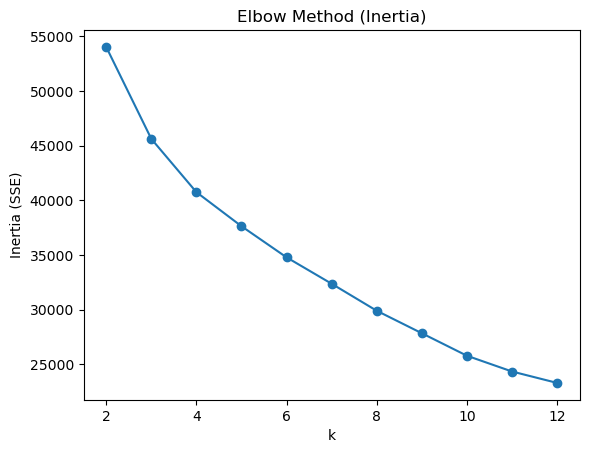

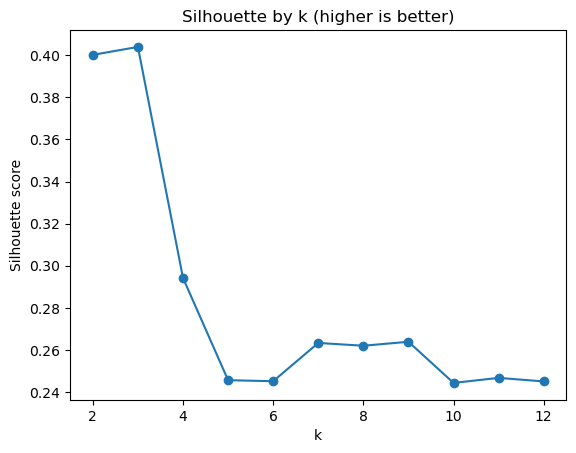

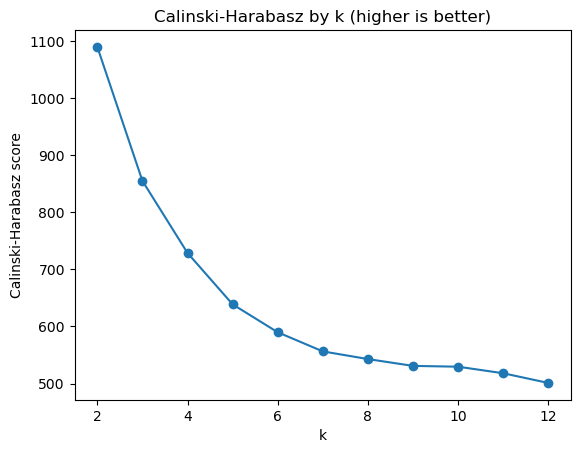

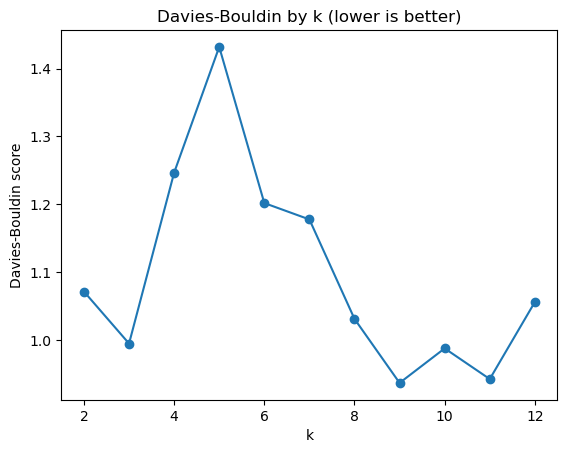

,k,silhouette,inertia,calinski_harabasz,davies_bouldin
0,3,0.403951,45633.507434,854.908717,0.994649
1,2,0.400183,54044.377904,1089.519774,1.071302
2,4,0.294218,40756.891153,728.708360,1.246506
3,9,0.263891,27843.870934,530.892679,0.936615
4,7,0.263338,32373.118907,556.305935,1.177603
5,8,0.262011,29900.891583,542.891403,1.031021
6,11,0.246745,24343.059993,518.019020,0.942290
7,5,0.245643,37637.943118,638.735526,1.431916
8,6,0.245160,34789.600112,589.848632,1.201744
9,12,0.245054,23298.208058,501.084061,1.055877


In [93]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

ks = range(2, 13)  # try 2..12
inertias = []
silhouettes = []
chs = []  # Calinski-Harabasz
dbs = []  # Davies-Bouldin (lower is better)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    chs.append(calinski_harabasz_score(X_scaled, labels))
    dbs.append(davies_bouldin_score(X_scaled, labels))

# Elbow plot
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (Inertia)")
plt.show()

# Silhouette plot
plt.figure()
plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette by k (higher is better)")
plt.show()

# Additional indices
plt.figure()
plt.plot(list(ks), chs, marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz score")
plt.title("Calinski-Harabasz by k (higher is better)")
plt.show()

plt.figure()
plt.plot(list(ks), dbs, marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin score")
plt.title("Davies-Bouldin by k (lower is better)")
plt.show()

# Print top k choices by silhouette
ranked = sorted(zip(ks, silhouettes, inertias, chs, dbs), key=lambda x: x[1], reverse=True)
pd.DataFrame(ranked, columns=["k","silhouette","inertia","calinski_harabasz","davies_bouldin"]).head(10)

In [94]:
from sklearn.metrics import adjusted_rand_score
import numpy as np

def fit_labels(k, seed):
    km = KMeans(n_clusters=k, random_state=seed, n_init=20)
    return km.fit_predict(X_scaled)

def stability_ari(k, seeds):
    labels_list = [fit_labels(k, s) for s in seeds]
    aris = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    return float(np.mean(aris)), float(np.std(aris))

seeds = [0, 1, 2, 3, 4, 10, 42, 99, 123, 2024]
stability_rows = []
for k in range(2, 13):
    mean_ari, std_ari = stability_ari(k, seeds)
    stability_rows.append((k, mean_ari, std_ari))

stability_df = pd.DataFrame(stability_rows, columns=["k", "mean_ARI", "std_ARI"])
stability_df.sort_values("mean_ARI", ascending=False).head(10)

,k,mean_ARI,std_ARI
0,2,1.000000,0.000000
1,3,0.997105,0.002175
2,4,0.988249,0.007930
8,10,0.982045,0.011930
9,11,0.967933,0.012715
5,7,0.930011,0.108088
4,6,0.918039,0.113190
6,8,0.896661,0.087160
7,9,0.895367,0.091614
3,5,0.845230,0.129361


K = 3 was selected because it provides the best overall balance across multiple clustering evaluation metrics. The silhouette score is highest at K = 3 (0.404), indicating strong within-cluster cohesion and clear separation between clusters. Although K = 2 has a slightly higher Calinski-Harabasz score, K = 3 substantially reduces inertia compared to K = 2 while maintaining a low Davies-Bouldin index (0.995), reflecting compact and well-separated clusters. For K ≥ 4, the silhouette score drops sharply and cluster quality deteriorates, suggesting that three clusters best capture meaningful engagement pattern heterogeneity without over-segmentation.


## 3.3 Fit final K-Means

In [95]:
best_k = 3

best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cluster_labels = best_kmeans.fit_predict(X_scaled)

df_labeled = df_cluster[[id_col]].copy()
df_labeled["cluster"] = cluster_labels

df_labeled["cluster"].value_counts().sort_index()

cluster
0       5
1    1252
2    1025
Name: count, dtype: int64

The cluster sizes are quite uneven, with a very small cluster of highly unusual behavior and two larger clusters representing the majority of students.

## 3.4 Interpreting Clusters

To interpret the behavior patterns in the clusters, I identify the most defining features for each cluster.

The process of obtaining most defining feautues is described as follows.

1. Before clustering, all features were standardized so that each one has mean 0 and standard deviation 1.
2. For each cluster, look at its centroid values in this standardized space by calling best_kmeans.cluster_centers_.
3. Calculate deviation of each cluster centriod from the feature average: A large positive or negative value means that students in that cluster are far above or far below the overall average on that feature.
4. Take the absolute value of these standardized differences and rank them from largest to smallest.
5. The features with the largest absolute standardized differences are considered the defining features, because they are the ones where that cluster stands out the most compared to the overall population.



In [ ]:
# 1) Get centroids in standardized space
centroids_z = best_kmeans.cluster_centers_  

centroids_z_df = pd.DataFrame(
    centroids_z,
    columns=X_df.columns,
    index=pd.Index(range(best_kmeans.n_clusters), name="cluster")
)

# 2) Centroids back to original scale to be interpretable
centroids_orig = scaler.inverse_transform(centroids_z)
centroids_orig_df = pd.DataFrame(
    centroids_orig,
    columns=X_df.columns,
    index=pd.Index(range(best_kmeans.n_clusters), name="cluster")
)

def top_cluster_features(centroids_z_df: pd.DataFrame, top_n: int = 8) -> dict:
    """
    Returns dict: cluster -> list of top_n features with largest |z| in that cluster.
    """
    top_feats = {}
    for c in centroids_z_df.index:
        top_feats[c] = (
            centroids_z_df.loc[c]
            .abs()
            .sort_values(ascending=False)
            .head(top_n)
            .index
            .tolist()
        )
    return top_feats

top_n = 8
top_feats_by_cluster = top_cluster_features(centroids_z_df, top_n=top_n)


summaries = []
for c, feats in top_feats_by_cluster.items():
    tmp = pd.DataFrame({
        "feature": feats,
        "z_score": centroids_z_df.loc[c, feats].values,              # comparable "importance"
        "centroid_original": centroids_orig_df.loc[c, feats].values  # interpretable behavior
    })
    tmp["cluster"] = c
    # Sort by |z| so the most defining features appear first
    tmp = tmp.sort_values(by="z_score", key=lambda s: s.abs(), ascending=False)
    summaries.append(tmp)

summary_df = pd.concat(summaries, ignore_index=True)

summary_df["z_score"] = summary_df["z_score"].round(3)
summary_df["centroid_original"] = summary_df["centroid_original"].round(3)

# 5) Print per-cluster results
for c in range(best_kmeans.n_clusters):
    print(f"\nCluster {c} — Top {top_n} defining features (ranked by |z|):")
    display(
        summary_df[summary_df["cluster"] == c][["feature", "z_score", "centroid_original"]]
        .reset_index(drop=True)
    )


Cluster 0 — Top 8 defining features (ranked by |z|):


,feature,z_score,centroid_original
0,pct_clicks_homepage,17.959,11.000
1,pct_clicks_subpage,16.081,7.183
2,pct_clicks_page,16.039,1.367
3,pct_clicks_resource,15.130,3.967
4,pct_clicks_oucontent,14.244,13.067
5,pct_clicks_forumng,14.047,7.450
6,pct_clicks_url,13.349,0.667
7,pct_clicks_ouwiki,6.559,0.133



Cluster 1 — Top 8 defining features (ranked by |z|):


,feature,z_score,centroid_original
0,submission_rate,0.868,0.894
1,total_assess_submitted,0.868,11.625
2,total_assess_missed,-0.840,2.399
3,missed_rate,-0.840,0.185
4,longest_inactive_streak,-0.809,50.633
5,active_weeks_ratio,0.805,0.355
6,course_completion_ratio,0.767,0.416
7,week_of_last_activity,0.767,35.768



Cluster 2 — Top 8 defining features (ranked by |z|):


,feature,z_score,centroid_original
0,submission_rate,-1.054,0.127
1,total_assess_submitted,-1.054,1.645
2,total_assess_missed,1.020,11.688
3,missed_rate,1.020,0.899
4,longest_inactive_streak,0.981,76.986
5,active_weeks_ratio,-0.976,0.078
6,week_of_last_activity,-0.931,10.528
7,course_completion_ratio,-0.931,0.122


**Cluster 0: Passive Browsers**
Students in this cluster mainly interact with navigation and content pages such as the homepage, subpages, and course content. Their engagement appears superficial, consisting mostly of browsing rather than participating in learning activities or assessments. This pattern suggests learners who explore the course interface but do not meaningfully engage with course requirements.

**Cluster 1: Highly Engaged Learners**
Students in this cluster demonstrate strong and consistent engagement throughout the course. They submit most assessments, remain active until late in the course timeline, and interact with course materials regularly. This group represents committed learners who persist and actively participate in course activities.

**Cluster 2: Early Disengaged Learners**
Students in this cluster show very low assessment participation and miss most required assignments. Their engagement occurs in only a small fraction of course weeks, and their activity typically stops early in the course. This pattern indicates learners who disengage early and are likely at high risk of dropping out.

**Visualization**

I visualized the clusters in a 2-D space after PCA. 

PC1 explains 14% of the variance, and PC2 explains 39% of the variance.

Although the clusters overlap somewhat, the visualization still shows clear separation between engagement groups, which supports the clustering results.

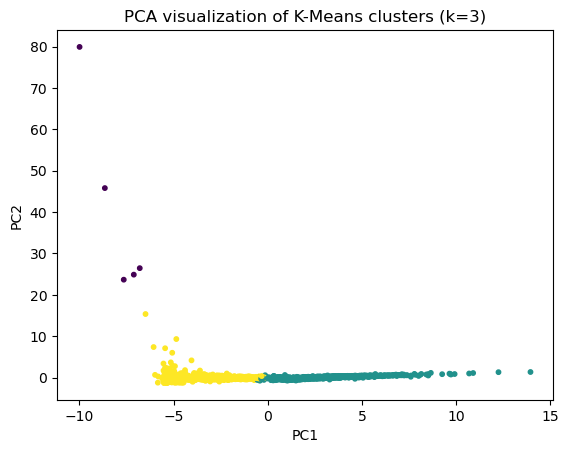

Explained variance ratio: [0.39015249 0.14317373]


In [97]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA visualization of K-Means clusters (k={best_k})")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)